# Laboratorio 7 - Spark MLlib
CC3066 - Data Science  

## Análisis exploratorio avanzado y segmentación

### Integrantes

- María José Girón Isidro
- Leonardo Dufrey Mejía Mejía
- Mia Alejandra Fuentes Mérida

---

## Objetivo

En este notebook se realiza la preparación, análisis exploratorio y
segmentación de los datos de Personas de la Encuesta Nacional de Empleo
e Ingresos Continua (ENEIC).

Para el desarrollo se utilizan los cuatro trimestres correspondientes
al año 2025. El primer trimestre de 2026 se mantiene separado para la
evaluación final.

In [1]:
import os
import math
import pandas as pd
import numpy as np
import openpyxl
import gc

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import matplotlib.pyplot as plt

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Laboratorio7-ENEIC")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Versión de Spark:", spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/28 01:52:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Versión de Spark: 3.5.1


In [3]:
print("Estoy trabajando en:")
print(os.getcwd())
print("Archivos disponibles:")
print(os.listdir("."))
print(os.listdir("./data"))

Estoy trabajando en:
/opt/app/work
Archivos disponibles:
['.git', '.gitignore', 'Base-de-datos-Personas-ENEIC-IV-2025.zip', 'data', 'Laboratorio7.ipynb', 'README.md']
['Base-de-datos-Personas-ENEIC-I-2026.xlsx', 'Base-de-datos-Personas-ENEIC-III-2025.xlsx', 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 'diccionarios', 'parquet', 'Personas-ENEIC-T2-2025.xlsx', 'Personas_ENEIC_T1_2025.xlsx']


## 1. Carga, armonización y calidad de datos

In [4]:
DATA_DIR = "./data"

ARCHIVOS = {
    "2025T1": {
        "ruta": f"{DATA_DIR}/Personas_ENEIC_T1_2025.xlsx",
        "anio": 2025,
        "trimestre": 1
    },
    "2025T2": {
        "ruta": f"{DATA_DIR}/Personas-ENEIC-T2-2025.xlsx",
        "anio": 2025,
        "trimestre": 2
    },
    "2025T3": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
        "anio": 2025,
        "trimestre": 3
    },
    "2025T4": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
        "anio": 2025,
        "trimestre": 4
    },
    "2026T1": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
        "anio": 2026,
        "trimestre": 1
    }
}

for periodo, info in ARCHIVOS.items():
    print(periodo, "->", os.path.exists(info["ruta"]))

2025T1 -> True
2025T2 -> True
2025T3 -> True
2025T4 -> True
2026T1 -> True


In [5]:
COLUMNAS_REQUERIDAS = [
    "P05D01",       # salario mensual
    "P02A03",       # edad
    "P05C07A",      # antigüedad años
    "P05C07B",      # antigüedad meses
    "P05H01A",      # horas semanales
    "P03A03A",      # nivel educativo
    "P05C16",       # categoría ocupacional
    "DOMINIO",      # dominio
    "OCUPADOS",     # condición de ocupado
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

RENOMBRES = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado"
}

In [6]:
for periodo, info in ARCHIVOS.items():

    encabezado = pd.read_excel(
        info["ruta"],
        engine="openpyxl",
        nrows=0
    )

    columnas = list(encabezado.columns)

    faltantes = [
        col for col in COLUMNAS_REQUERIDAS
        if col not in columnas
    ]

    print(f"\n{periodo}")
    print(f"Columnas totales: {len(columnas)}")
    print(f"Columnas requeridas faltantes: {faltantes}")


2025T1
Columnas totales: 270
Columnas requeridas faltantes: []

2025T2
Columnas totales: 270
Columnas requeridas faltantes: []

2025T3
Columnas totales: 270
Columnas requeridas faltantes: []

2025T4
Columnas totales: 302
Columnas requeridas faltantes: []



2026T1
Columnas totales: 270
Columnas requeridas faltantes: []


In [7]:
PARQUET_DIR = "./data/parquet"

os.makedirs(PARQUET_DIR, exist_ok=True)

print("Directorio creado:", PARQUET_DIR)

Directorio creado: ./data/parquet


In [8]:
ruta_t1 = ARCHIVOS["2025T1"]["ruta"]

pdf_t1 = pd.read_excel(
    ruta_t1,
    engine="openpyxl",
    usecols=COLUMNAS_REQUERIDAS
)

print("Dimensiones:", pdf_t1.shape)
display(pdf_t1.head())

Dimensiones: (51588, 14)


,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A,OCUPADOS
0,2025,2,2,13796,338,3,14,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,2,13796,338,1,42,5.0,23.0,0.0,6.0,NaN,35.0,1.0
2,2025,2,2,13796,338,2,42,5.0,20.0,0.0,1.0,7000.0,1.0,1.0
3,2025,2,2,13796,338,5,9,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,2,2,13796,338,4,11,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
pdf_t1.info()


<class 'pandas.DataFrame'>
RangeIndex: 51588 entries, 0 to 51587
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ANIO         51588 non-null  int64  
 1   TRIMESTRE    51588 non-null  int64  
 2   DOMINIO      51588 non-null  int64  
 3   NUM_HOGAR    51588 non-null  int64  
 4   FACTOR       51588 non-null  int64  
 5   NUM_PERSONA  51588 non-null  int64  
 6   P02A03       51588 non-null  int64  
 7   P03A03A      44660 non-null  float64
 8   P05C07A      22273 non-null  float64
 9   P05C07B      22273 non-null  float64
 10  P05C16       22273 non-null  float64
 11  P05D01       13419 non-null  float64
 12  P05H01A      22273 non-null  float64
 13  OCUPADOS     22273 non-null  float64
dtypes: float64(7), int64(7)
memory usage: 5.5 MB


In [10]:
display(pdf_t1.head(10))

,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A,OCUPADOS
0,2025,2,2,13796,338,3,14,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,2,13796,338,1,42,5.0,23.0,0.0,6.0,NaN,35.0,1.0
2,2025,2,2,13796,338,2,42,5.0,20.0,0.0,1.0,7000.0,1.0,1.0
3,2025,2,2,13796,338,5,9,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,2,2,13796,338,4,11,2.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2025,2,2,5636,580,4,22,4.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2025,2,2,5636,580,2,41,2.0,0.0,3.0,4.0,800.0,25.0,1.0
7,2025,2,2,5636,580,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2025,2,2,5636,580,1,45,2.0,0.0,1.0,7.0,NaN,25.0,1.0
9,2025,2,2,5636,580,3,20,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
for columna in COLUMNAS_REQUERIDAS:
    print(f"\n--- {columna} ---")
    print("Tipo:", pdf_t1[columna].dtype)
    print("Ejemplos:", pdf_t1[columna].dropna().unique()[:10])


--- P05D01 ---
Tipo: float64
Ejemplos: [7000.  800. 2300. 3000. 1600. 3400. 2500. 3800.  600. 1920.]

--- P02A03 ---
Tipo: int64
Ejemplos: [14 42  9 11 22 41  0 45 20 31]

--- P05C07A ---
Tipo: float64
Ejemplos: [23. 20.  0.  5.  6. 52.  1. 35. 25.  3.]

--- P05C07B ---
Tipo: float64
Ejemplos: [ 0.  3.  1.  6.  2.  5.  9. 11. 10.  7.]

--- P05H01A ---
Tipo: float64
Ejemplos: [35.  1. 25. 21. 36. 20. 24. 63. 42. 77.]

--- P03A03A ---
Tipo: float64
Ejemplos: [3. 5. 2. 4. 0. 1. 6. 7.]

--- P05C16 ---
Tipo: float64
Ejemplos: [6. 1. 4. 7. 5. 3. 2. 9. 8.]

--- DOMINIO ---
Tipo: int64
Ejemplos: [2 3 1]

--- OCUPADOS ---
Tipo: float64
Ejemplos: [1.]

--- NUM_HOGAR ---
Tipo: int64
Ejemplos: [13796  5636  8825 13797 13798  2713  9465  5052  8784 13799]

--- NUM_PERSONA ---
Tipo: int64
Ejemplos: [ 3  1  2  5  4  7  6  9  8 10]

--- FACTOR ---
Tipo: int64
Ejemplos: [338 580 562 216 552 181  68 620 200 686]

--- ANIO ---
Tipo: int64
Ejemplos: [2025]

--- TRIMESTRE ---
Tipo: int64
Ejemplos: [2]


In [12]:
print(pdf_t1["ANIO"].value_counts(dropna=False))

print(pdf_t1["TRIMESTRE"].value_counts(dropna=False))

ANIO
2025    51588
Name: count, dtype: int64
TRIMESTRE
2    51588
Name: count, dtype: int64


In [13]:
COLUMNAS_NUMERICAS = [
    "P05D01",
    "P02A03",
    "P05C07A",
    "P05C07B",
    "P05H01A",
    "OCUPADOS",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

COLUMNAS_CATEGORICAS = [
    "P03A03A",
    "P05C16",
    "DOMINIO",
    "NUM_HOGAR",
    "NUM_PERSONA"
]

In [14]:
def cargar_y_armonizar_excel(periodo, info):

    print(f"Procesando {periodo}...")

    # Leer solamente las columnas necesarias
    pdf = pd.read_excel(
        info["ruta"],
        engine="openpyxl",
        usecols=COLUMNAS_REQUERIDAS
    )

    registros_originales = len(pdf)

    # Homologar variables numéricas
    for col in COLUMNAS_NUMERICAS:
        pdf[col] = pd.to_numeric(
            pdf[col],
            errors="coerce"
        )

    # Homologar códigos categóricos
    for col in COLUMNAS_CATEGORICAS:

        pdf[col] = pdf[col].astype("string")

        # Ejemplo: "1.0" -> "1"
        pdf[col] = pdf[col].str.replace(
            r"\.0$",
            "",
            regex=True
        )

    # Renombrar variables analíticas
    pdf = pdf.rename(columns=RENOMBRES)

    # Variables de trazabilidad
    pdf["archivo_origen"] = os.path.basename(info["ruta"])
    pdf["periodo_archivo"] = periodo
    pdf["anio_archivo"] = int(info["anio"])
    pdf["trimestre_calendario"] = int(info["trimestre"])

    print(
        f"{periodo}: "
        f"{registros_originales:,} registros"
    )

    return pdf

In [15]:
prueba_t1 = cargar_y_armonizar_excel(
    "2025T1",
    ARCHIVOS["2025T1"]
)

print(prueba_t1.shape)

display(prueba_t1.head())

Procesando 2025T1...


2025T1: 51,588 registros
(51588, 18)


,ANIO,TRIMESTRE,dominio,NUM_HOGAR,FACTOR,NUM_PERSONA,edad,nivel_educativo,antiguedad_anios,antiguedad_meses,categoria_ocupacional,salario_mensual,horas_semanales,ocupado,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario
0,2025,2,2,13796,338,3,14,3,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
1,2025,2,2,13796,338,1,42,5,23.0,0.0,6,NaN,35.0,1.0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
2,2025,2,2,13796,338,2,42,5,20.0,0.0,1,7000.0,1.0,1.0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
3,2025,2,2,13796,338,5,9,2,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
4,2025,2,2,13796,338,4,11,2,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1


In [16]:
display(
    prueba_t1[
        [
            "ANIO",
            "TRIMESTRE",
            "archivo_origen",
            "periodo_archivo",
            "anio_archivo",
            "trimestre_calendario"
        ]
    ].head()
)

,ANIO,TRIMESTRE,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario
0,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
1,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
2,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
3,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
4,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1


In [17]:
conteos_originales = {}

for periodo, info in ARCHIVOS.items():

    print("\n" + "=" * 50)
    print(f"INICIANDO {periodo}")
    print("=" * 50)

    # 1. Excel -> pandas
    pdf = cargar_y_armonizar_excel(periodo, info)

    conteos_originales[periodo] = len(pdf)

    # 2. Cambiar pd.NA / NaN por None donde corresponda
    pdf_spark = pdf.astype(object).where(pd.notnull(pdf), None)

    # 3. pandas -> Spark
    sdf = spark.createDataFrame(pdf_spark)

    # 4. Guardar como Parquet
    ruta_salida = f"{PARQUET_DIR}/{periodo}"

    (
        sdf.write
        .mode("overwrite")
        .parquet(ruta_salida)
    )

    print(f"Parquet guardado en: {ruta_salida}")
    print(f"Registros: {sdf.count():,}")

    # 5. Liberar memoria
    del pdf
    del pdf_spark
    del sdf

    gc.collect()

print("\nConversión terminada.")


INICIANDO 2025T1
Procesando 2025T1...


2025T1: 51,588 registros


Parquet guardado en: ./data/parquet/2025T1


Registros: 51,588

INICIANDO 2025T2
Procesando 2025T2...


2025T2: 51,167 registros


...

Parquet guardado en: ./data/parquet/2025T4


Registros: 49,338

INICIANDO 2026T1
Procesando 2026T1...


2026T1: 49,843 registros


Parquet guardado en: ./data/parquet/2026T1


Registros: 49,843

Conversión terminada.


In [18]:
print("REGISTROS ORIGINALES")
print("-" * 35)

for periodo, cantidad in conteos_originales.items():
    print(f"{periodo}: {cantidad:,}")

REGISTROS ORIGINALES
-----------------------------------
2025T1: 51,588
2025T2: 51,167
2025T3: 51,583
2025T4: 49,338
2026T1: 49,843


In [19]:
df_2025_t1 = spark.read.parquet(f"{PARQUET_DIR}/2025T1")
df_2025_t2 = spark.read.parquet(f"{PARQUET_DIR}/2025T2")
df_2025_t3 = spark.read.parquet(f"{PARQUET_DIR}/2025T3")
df_2025_t4 = spark.read.parquet(f"{PARQUET_DIR}/2025T4")

df_2026 = spark.read.parquet(f"{PARQUET_DIR}/2026T1")

In [20]:
df_2025 = (
    df_2025_t1
    .unionByName(df_2025_t2)
    .unionByName(df_2025_t3)
    .unionByName(df_2025_t4)
)

In [21]:
total_2025 = df_2025.count()

print(f"Total registros 2025: {total_2025:,}")

Total registros 2025: 203,676


In [22]:
df_2025.printSchema()

root
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- dominio: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- edad: long (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)



In [23]:
df_2025.show(5, truncate=False)

+----+---------+-------+---------+------+-----------+----+---------------+----------------+----------------+---------------------+---------------+---------------+-------+---------------------------+---------------+------------+--------------------+
|ANIO|TRIMESTRE|dominio|NUM_HOGAR|FACTOR|NUM_PERSONA|edad|nivel_educativo|antiguedad_anios|antiguedad_meses|categoria_ocupacional|salario_mensual|horas_semanales|ocupado|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|
+----+---------+-------+---------+------+-----------+----+---------------+----------------+----------------+---------------------+---------------+---------------+-------+---------------------------+---------------+------------+--------------------+
|2025|2        |2      |12647    |519   |1          |80  |2              |NULL            |NULL            |NULL                 |NULL           |NULL           |NULL   |Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |
|202

In [24]:
(
    df_2025
    .groupBy(
        "periodo_archivo",
        "anio_archivo",
        "trimestre_calendario"
    )
    .count()
    .orderBy("periodo_archivo")
    .show()
)

+---------------+------------+--------------------+-----+
|periodo_archivo|anio_archivo|trimestre_calendario|count|
+---------------+------------+--------------------+-----+
|         2025T1|        2025|                   1|51588|
|         2025T2|        2025|                   2|51167|
|         2025T3|        2025|                   3|51583|
|         2025T4|        2025|                   4|49338|
+---------------+------------+--------------------+-----+



In [25]:
(
    df_2025
    .groupBy(
        "periodo_archivo",
        "TRIMESTRE"
    )
    .count()
    .orderBy(
        "periodo_archivo",
        "TRIMESTRE"
    )
    .show()
)

+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025T1|        2|51588|
|         2025T2|        2|  175|
|         2025T2|        3|50992|
|         2025T3|        4|51583|
|         2025T4|        5|49338|
+---------------+---------+-----+



### Identificación del período

Se conservó la variable `TRIMESTRE` tal como aparece en las bases
originales. Sin embargo, esta variable no se utilizó directamente para
identificar el trimestre calendario.

En su lugar, se construyeron las variables `periodo_archivo`,
`anio_archivo` y `trimestre_calendario` utilizando el archivo de
procedencia de cada observación.

Esta decisión evita asumir que los códigos originales de `TRIMESTRE`
corresponden directamente al trimestre calendario y permite mantener
trazabilidad respecto de la fuente original.

In [26]:
columnas_analisis = [
    "salario_mensual",
    "edad",
    "antiguedad_anios",
    "antiguedad_meses",
    "horas_semanales",
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio",
    "ocupado",
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

total = df_2025.count()

faltantes_expr = []

for col in columnas_analisis:
    faltantes_expr.append(
        F.sum(
            F.when(F.col(col).isNull(), 1).otherwise(0)
        ).alias(col)
    )

fila_faltantes = df_2025.agg(*faltantes_expr).first()

datos_faltantes = []

for col in columnas_analisis:
    n = fila_faltantes[col]

    datos_faltantes.append(
        (
            col,
            n,
            round(n / total * 100, 2)
        )
    )

df_faltantes = spark.createDataFrame(
    datos_faltantes,
    ["variable", "faltantes", "porcentaje"]
)

df_faltantes.show(30, truncate=False)

+---------------------+---------+----------+
|variable             |faltantes|porcentaje|
+---------------------+---------+----------+
|salario_mensual      |150651   |73.97     |
|edad                 |0        |0.0       |
|antiguedad_anios     |115454   |56.69     |
|antiguedad_meses     |115454   |56.69     |
|horas_semanales      |115454   |56.69     |
|nivel_educativo      |26344    |12.93     |
|categoria_ocupacional|115454   |56.69     |
|dominio              |0        |0.0       |
|ocupado              |115454   |56.69     |
|NUM_HOGAR            |0        |0.0       |
|NUM_PERSONA          |0        |0.0       |
|FACTOR               |0        |0.0       |
|ANIO                 |0        |0.0       |
|TRIMESTRE            |0        |0.0       |
+---------------------+---------+----------+



In [27]:
claves = [
    "periodo_archivo",
    "NUM_HOGAR",
    "NUM_PERSONA"
]

duplicados = (
    df_2025
    .groupBy(*claves)
    .count()
    .filter(F.col("count") > 1)
)

cantidad_claves_duplicadas = duplicados.count()

print(
    "Cantidad de claves con más de un registro:",
    cantidad_claves_duplicadas
)

Cantidad de claves con más de un registro: 0


In [28]:
duplicados.orderBy(F.desc("count")).show(
    20,
    truncate=False
)

+---------------+---------+-----------+-----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+



In [29]:
df_2025_preparacion = df_2025.withColumn(
    "antiguedad",
    F.col("antiguedad_anios")
    + F.col("antiguedad_meses") / F.lit(12.0)
)

In [30]:
df_2025_preparacion.select(
    "antiguedad_anios",
    "antiguedad_meses",
    "antiguedad"
).show(10)

+----------------+----------------+----------+
|antiguedad_anios|antiguedad_meses|antiguedad|
+----------------+----------------+----------+
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|             4.0|             0.0|       4.0|
|            NULL|            NULL|      NULL|
+----------------+----------------+----------+
only showing top 10 rows



In [31]:
def aplicar_filtro_y_contar(df, nombre, condicion):
    antes = df.count()

    nuevo_df = df.filter(condicion)

    despues = nuevo_df.count()
    excluidos = antes - despues

    return nuevo_df, {
        "paso": nombre,
        "antes": antes,
        "excluidos": excluidos,
        "despues": despues
    }

In [32]:
df_limpio = df_2025_preparacion

auditoria_filtros = []

In [33]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Edad finita y >= 15",
    F.col("edad").isNotNull()
    & (~F.isnan(F.col("edad").cast("double")))
    & (F.col("edad") >= 15)
)

auditoria_filtros.append(resultado)

In [34]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "OCUPADOS = 1",
    F.col("ocupado") == 1
)

auditoria_filtros.append(resultado)

In [35]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "P05C16 en {1,2,3,4}",
    F.col("categoria_ocupacional").isin(
        "1", "2", "3", "4"
    )
)

auditoria_filtros.append(resultado)

In [36]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Salario finito y > 0",
    F.col("salario_mensual").isNotNull()
    & (~F.isnan("salario_mensual"))
    & (F.col("salario_mensual") > 0)
)

auditoria_filtros.append(resultado)

In [37]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Antigüedad en años no negativa",
    F.col("antiguedad_anios").isNotNull()
    & (~F.isnan("antiguedad_anios"))
    & (F.col("antiguedad_anios") >= 0)
)

auditoria_filtros.append(resultado)

In [38]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Meses enteros entre 0 y 11",
    F.col("antiguedad_meses").isNotNull()
    & (~F.isnan("antiguedad_meses"))
    & (F.col("antiguedad_meses") >= 0)
    & (F.col("antiguedad_meses") <= 11)
    & (
        F.col("antiguedad_meses")
        == F.floor(F.col("antiguedad_meses"))
    )
)

auditoria_filtros.append(resultado)

In [39]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Antigüedad <= edad",
    F.col("antiguedad").isNotNull()
    & (F.col("antiguedad") <= F.col("edad"))
)

auditoria_filtros.append(resultado)

In [40]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "0 < horas semanales <= 168",
    F.col("horas_semanales").isNotNull()
    & (~F.isnan("horas_semanales"))
    & (F.col("horas_semanales") > 0)
    & (F.col("horas_semanales") <= 168)
)

auditoria_filtros.append(resultado)

In [41]:
df_auditoria = spark.createDataFrame(auditoria_filtros)

df_auditoria.select(
    "paso",
    "antes",
    "excluidos",
    "despues"
).show(
    truncate=False
)

+------------------------------+------+---------+-------+
|paso                          |antes |excluidos|despues|
+------------------------------+------+---------+-------+
|Edad finita y >= 15           |203676|62886    |140790 |
|OCUPADOS = 1                  |140790|52568    |88222  |
|P05C16 en {1,2,3,4}           |88222 |35197    |53025  |
|Salario finito y > 0          |53025 |0        |53025  |
|Antigüedad en años no negativa|53025 |0        |53025  |
|Meses enteros entre 0 y 11    |53025 |0        |53025  |
|Antigüedad <= edad            |53025 |0        |53025  |
|0 < horas semanales <= 168    |53025 |0        |53025  |
+------------------------------+------+---------+-------+



In [42]:
print(f"Registros iniciales: {df_2025.count():,}")
print(f"Registros analíticos finales: {df_limpio.count():,}")

Registros iniciales: 203,676


Registros analíticos finales: 53,025


In [43]:
antes_por_archivo = (
    df_2025
    .groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "antes")
)

despues_por_archivo = (
    df_limpio
    .groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "despues")
)

In [44]:
comparacion_archivos = (
    antes_por_archivo
    .join(
        despues_por_archivo,
        on="periodo_archivo",
        how="left"
    )
    .withColumn(
        "excluidos",
        F.col("antes") - F.col("despues")
    )
    .withColumn(
        "porcentaje_conservado",
        F.round(
            F.col("despues") / F.col("antes") * 100,
            2
        )
    )
    .orderBy("periodo_archivo")
)

comparacion_archivos.show()

+---------------+-----+-------+---------+---------------------+
|periodo_archivo|antes|despues|excluidos|porcentaje_conservado|
+---------------+-----+-------+---------+---------------------+
|         2025T1|51588|  13419|    38169|                26.01|
|         2025T2|51167|  13492|    37675|                26.37|
|         2025T3|51583|  13450|    38133|                26.07|
|         2025T4|49338|  12664|    36674|                25.67|
+---------------+-----+-------+---------+---------------------+



### Calidad de datos y aplicación de filtros

La base combinada de 2025 contiene 203,676 observaciones antes de
aplicar los criterios de selección de la población analítica.

El análisis de faltantes se realizó antes de los filtros. Se observó
una proporción elevada de valores ausentes en variables laborales,
incluyendo salario mensual, antigüedad, horas semanales y categoría
ocupacional. Estos porcentajes deben interpretarse considerando que
la base inicial incluye a todas las personas registradas y no
únicamente a trabajadores asalariados.

Los filtros se aplicaron de forma secuencial y en un orden fijo.
El criterio de edad redujo la base de 203,676 a 140,790 registros.
Posteriormente, la condición de ocupado redujo el conjunto a 88,222
observaciones y la selección de las categorías ocupacionales 1, 2, 3
y 4 produjo una población analítica de 53,025 registros.

Una vez definida esta población, los criterios posteriores de salario
positivo, antigüedad válida y horas semanales válidas no produjeron
exclusiones adicionales.

Finalmente, se verificó la unicidad de la combinación
`periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA`. No se encontraron
claves duplicadas dentro de un mismo período.

### Validación de variables categóricas contra el diccionario

Los diccionarios de los cinco archivos definen los mismos códigos:

| Variable | Códigos válidos |
|---|---|
| `nivel_educativo` (P03A03A) | 0 Ninguno, 1 Preprimaria, 2 Primaria, 3 Básico, 4 Diversificado, 5 Superior, 6 Maestría, 7 Doctorado |
| `categoria_ocupacional` (P05C16) | 1 a 9 (en la población analítica solo 1 a 4) |
| `dominio` | 1 Urbano metropolitano, 2 Resto urbano, 3 Rural nacional |

Cualquier valor ausente o fuera de estos códigos se representa como `DESCONOCIDO`.
El código educativo `0` significa "ninguno" y se conserva como una categoría válida.

In [45]:
CODIGOS_VALIDOS = {
    "nivel_educativo": ["0", "1", "2", "3", "4", "5", "6", "7"],
    "categoria_ocupacional": ["1", "2", "3", "4", "5", "6", "7", "8", "9"],
    "dominio": ["1", "2", "3"],
}

ETIQUETAS = {
    "nivel_educativo": {
        "0": "Ninguno", "1": "Preprimaria", "2": "Primaria", "3": "Básico",
        "4": "Diversificado", "5": "Superior", "6": "Maestría",
        "7": "Doctorado", "DESCONOCIDO": "Desconocido",
    },
    "categoria_ocupacional": {
        "1": "Gobierno", "2": "Empresa privada", "3": "Jornalero/peón",
        "4": "Servicio doméstico", "DESCONOCIDO": "Desconocido",
    },
    "dominio": {
        "1": "Urbano metropolitano", "2": "Resto urbano",
        "3": "Rural nacional", "DESCONOCIDO": "Desconocido",
    },
}


def validar_categoricas(df):
    for col, validos in CODIGOS_VALIDOS.items():
        valor = F.trim(F.col(col).cast("string"))
        df = df.withColumn(
            col,
            F.when(valor.isin(validos), valor).otherwise(F.lit("DESCONOCIDO"))
        )
    return df


def contar_desconocidos(df):
    return df.agg(*[
        F.sum(F.when(F.col(c) == "DESCONOCIDO", 1).otherwise(0)).alias(c)
        for c in CODIGOS_VALIDOS
    ])


print("DESCONOCIDO en la base completa de 2025 (antes de filtros):")
contar_desconocidos(validar_categoricas(df_2025)).show()

DESCONOCIDO en la base completa de 2025 (antes de filtros):


+---------------+---------------------+-------+
|nivel_educativo|categoria_ocupacional|dominio|
+---------------+---------------------+-------+
|          26344|               115454|      0|
+---------------+---------------------+-------+



### Función de preparación reutilizable

Para aplicar exactamente las mismas reglas al primer trimestre de 2026, las
condiciones se agrupan en una lista con el mismo orden utilizado para 2025.

In [46]:
FILTROS = [
    ("Edad finita y >= 15",
     F.col("edad").isNotNull()
     & (~F.isnan(F.col("edad").cast("double")))
     & (F.col("edad") >= 15)),
    ("OCUPADOS = 1",
     F.col("ocupado") == 1),
    ("P05C16 en {1,2,3,4}",
     F.col("categoria_ocupacional").isin("1", "2", "3", "4")),
    ("Salario finito y > 0",
     F.col("salario_mensual").isNotNull()
     & (~F.isnan(F.col("salario_mensual").cast("double")))
     & (F.col("salario_mensual") > 0)),
    ("Antigüedad en años no negativa",
     F.col("antiguedad_anios").isNotNull()
     & (~F.isnan(F.col("antiguedad_anios").cast("double")))
     & (F.col("antiguedad_anios") >= 0)),
    ("Meses enteros entre 0 y 11",
     F.col("antiguedad_meses").isNotNull()
     & (~F.isnan(F.col("antiguedad_meses").cast("double")))
     & (F.col("antiguedad_meses") >= 0)
     & (F.col("antiguedad_meses") <= 11)
     & (F.col("antiguedad_meses") == F.floor(F.col("antiguedad_meses")))),
    ("Antigüedad <= edad",
     F.col("antiguedad").isNotNull()
     & (F.col("antiguedad") <= F.col("edad"))),
    ("0 < horas semanales <= 168",
     F.col("horas_semanales").isNotNull()
     & (~F.isnan(F.col("horas_semanales").cast("double")))
     & (F.col("horas_semanales") > 0)
     & (F.col("horas_semanales") <= 168)),
]


def preparar_poblacion(df):
    df = df.withColumn(
        "antiguedad",
        F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
    )

    auditoria = []
    for nombre, condicion in FILTROS:
        df, resultado = aplicar_filtro_y_contar(df, nombre, condicion)
        auditoria.append(resultado)

    return validar_categoricas(df), auditoria

In [47]:
df_2025_final = validar_categoricas(df_limpio)

df_2026_final, auditoria_2026 = preparar_poblacion(df_2026)

print("Filtros aplicados a 2026T1 (mismo orden que 2025):")
spark.createDataFrame(auditoria_2026).select(
    "paso", "antes", "excluidos", "despues"
).show(truncate=False)

print("Valores DESCONOCIDO en la población analítica 2025:")
contar_desconocidos(df_2025_final).show()

print("Valores DESCONOCIDO en la población analítica 2026:")
contar_desconocidos(df_2026_final).show()

Filtros aplicados a 2026T1 (mismo orden que 2025):


+------------------------------+-----+---------+-------+
|paso                          |antes|excluidos|despues|
+------------------------------+-----+---------+-------+
|Edad finita y >= 15           |49843|14803    |35040  |
|OCUPADOS = 1                  |35040|13306    |21734  |
|P05C16 en {1,2,3,4}           |21734|8476     |13258  |
|Salario finito y > 0          |13258|0        |13258  |
|Antigüedad en años no negativa|13258|0        |13258  |
|Meses enteros entre 0 y 11    |13258|0        |13258  |
|Antigüedad <= edad            |13258|0        |13258  |
|0 < horas semanales <= 168    |13258|0        |13258  |
+------------------------------+-----+---------+-------+

Valores DESCONOCIDO en la población analítica 2025:


+---------------+---------------------+-------+
|nivel_educativo|categoria_ocupacional|dominio|
+---------------+---------------------+-------+
|              0|                    0|      0|
+---------------+---------------------+-------+

Valores DESCONOCIDO en la población analítica 2026:


+---------------+---------------------+-------+
|nivel_educativo|categoria_ocupacional|dominio|
+---------------+---------------------+-------+
|              0|                    0|      0|
+---------------+---------------------+-------+



### Resultados de la validación y de la preparación de 2026

- Antes de filtrar, 26,344 registros de 2025 no tienen un nivel educativo válido y
  115,454 no tienen categoría ocupacional. Casi todos son **faltantes estructurales**:
  menores de edad o personas no ocupadas, a quienes el cuestionario no les hace esas
  preguntas. Ya dentro de la población analítica no queda ningún `DESCONOCIDO`, ni en 2025
  ni en 2026.
- En 2026T1 los filtros, aplicados en el mismo orden, reducen la base de 49,843 a 35,040
  (edad ≥ 15), luego a 21,734 (ocupados) y por último a **13,258 asalariados**. Se conserva
  el 26.6% de los registros, una proporción muy similar a la de los trimestres de 2025
  (entre 25.7% y 26.4%). Esto indica que el archivo de prueba tiene una composición comparable.
- Al igual que en 2025, los filtros de salario, antigüedad y horas no excluyen ningún registro
  adicional. En los asalariados ocupados, esos campos siempre vienen completos y dentro de
  rangos válidos.

In [48]:
claves = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

for nombre, df in [("2025 (todas las filas)", df_2025),
                   ("2026 (todas las filas)", df_2026)]:
    n_filas = df.count()
    n_claves = df.select(*claves).distinct().count()
    print(f"{nombre}: filas={n_filas:,}  claves distintas={n_claves:,}  "
          f"claves repetidas={n_filas - n_claves:,}")

2025 (todas las filas): filas=203,676  claves distintas=203,676  claves repetidas=0


2026 (todas las filas): filas=49,843  claves distintas=49,843  claves repetidas=0


No se encontraron claves repetidas en ninguno de los conjuntos, por lo que no fue
necesario distinguir entre repeticiones exactas y registros en conflicto, ni se
utilizó `dropDuplicates()`.

### Guardado del conjunto preparado

Se guardan por separado la población analítica de 2025 (entrenamiento y
validación) y la de 2026 (prueba final). Se conserva `FACTOR`, aunque no se usa
en el clustering ni en los modelos.

In [49]:
COLUMNAS_FINALES = [
    "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses",
    "antiguedad", "horas_semanales", "nivel_educativo",
    "categoria_ocupacional", "dominio", "ocupado",
]

(
    df_2025_final.select(*COLUMNAS_FINALES)
    .write.mode("overwrite")
    .parquet(f"{PARQUET_DIR}/preparado_2025")
)

(
    df_2026_final.select(*COLUMNAS_FINALES)
    .write.mode("overwrite")
    .parquet(f"{PARQUET_DIR}/preparado_2026")
)

df_2025_final = spark.read.parquet(f"{PARQUET_DIR}/preparado_2025").cache()
df_2026_final = spark.read.parquet(f"{PARQUET_DIR}/preparado_2026").cache()

print(f"Preparado 2025: {df_2025_final.count():,} registros")
print(f"Preparado 2026: {df_2026_final.count():,} registros")
df_2025_final.printSchema()

Preparado 2025: 53,025 registros


Preparado 2026: 13,258 registros
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: long (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: double (nullable = true)



### Respuestas — Sección 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
El archivo de IV de 2025 tiene 302 columnas y los demás 270. Las 32 columnas
adicionales desplazan la posición de las variables, así que una unión por posición
pondría valores de una variable bajo el nombre de otra sin generar ningún error. Por eso
primero se seleccionan las 14 columnas requeridas por nombre, se homologan los tipos y se
usa `unionByName`, que alinea las columnas por su nombre y no por su orden.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
El primero es un faltante *estructural*: el flujo del cuestionario no aplica esa pregunta
a la persona. Por ejemplo, a alguien desocupado, inactivo o que trabaja por cuenta propia no se le pregunta
el sueldo de asalariado (P05D01). No es un error y no debe imputarse. El segundo es una *no respuesta*:
la pregunta sí correspondía, pero no se registró (no sabe, no respondió u omisión).
Esto sí es un problema de calidad y puede introducir sesgo. Los porcentajes de faltantes
de la base completa son altos sobre todo por el primer tipo, porque la base incluye a todas las
personas del hogar. Dentro de la población analítica, ningún asalariado ocupado quedó
excluido por salario nulo o no positivo.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
La ENEIC es un panel rotativo: la misma persona puede ser entrevistada en trimestres
distintos y cada entrevista es una observación válida de un período diferente, que puede tener
otro salario, otras horas u otra antigüedad. La unidad de análisis es persona-período, y por eso la clave
incluye `periodo_archivo`. Eliminar esas filas descartaría información real y cambiaría la
composición de la muestra. Sí hay que tener en cuenta que las observaciones no son independientes,
porque una misma persona puede estar tanto en entrenamiento como en prueba.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
(1) Es una muestra probabilística, no un censo. Cada registro representa a muchas personas
según su `FACTOR` de expansión. (2) Los resultados son no ponderados. (3) Solo se incluyen
asalariados (códigos 1–4) con salario positivo registrado, lo que deja fuera a trabajadores por cuenta
propia, patronos y trabajadores no remunerados, que son una parte grande del empleo en
Guatemala. (4) Al unir cuatro trimestres, una misma persona puede contarse varias veces.

**Uso de `FACTOR`.** El factor de expansión indica cuántas personas de la población
representa cada registro. En un análisis poblacional se usaría como ponderador para estimar
totales, proporciones, medias y percentiles, idealmente junto con la información del
diseño (estratos y conglomerados) para calcular errores estándar correctos. En este
laboratorio se conserva solo como documentación, porque el alcance acordado es no ponderado.

## 2. Estadística descriptiva y preguntas de exploración

In [50]:
for columna in [
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio"
]:
    print("\n", "=" * 50)
    print(columna)

    (
        df_limpio
        .groupBy(columna)
        .count()
        .orderBy(columna)
        .show(50, truncate=False)
    )


nivel_educativo


+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|0              |3995 |
|1              |459  |
|2              |15822|
|3              |8249 |
|4              |16851|
|5              |6818 |
|6              |771  |
|7              |60   |
+---------------+-----+


categoria_ocupacional


+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|1                    |6575 |
|2                    |28702|
|3                    |13842|
|4                    |3906 |
+---------------------+-----+


dominio


+-------+-----+
|dominio|count|
+-------+-----+
|1      |22072|
|2      |20146|
|3      |10807|
+-------+-----+



In [51]:
variables_numericas = [
    "salario_mensual",
    "edad",
    "antiguedad",
    "horas_semanales"
]

estadisticas = []

for variable in variables_numericas:

    fila = df_limpio.agg(
        F.count(variable).alias("n"),
        F.mean(variable).alias("media"),
        F.stddev(variable).alias("desv_std"),
        F.min(variable).alias("minimo"),
        F.max(variable).alias("maximo"),
        F.percentile_approx(variable, 0.25).alias("p25"),
        F.percentile_approx(variable, 0.50).alias("mediana"),
        F.percentile_approx(variable, 0.75).alias("p75"),
        F.percentile_approx(variable, 0.95).alias("p95")
    ).first()

    estadisticas.append(
        (
            variable,
            fila["n"],
            fila["media"],
            fila["mediana"],
            fila["desv_std"],
            fila["minimo"],
            fila["maximo"],
            fila["p25"],
            fila["p75"],
            fila["p95"]
        )
    )

estadisticas_limpias = [
    (
        str(variable),
        int(n),
        float(media),
        float(mediana),
        float(desv_std),
        float(minimo),
        float(maximo),
        float(p25),
        float(p75),
        float(p95)
    )
    for (
        variable,
        n,
        media,
        mediana,
        desv_std,
        minimo,
        maximo,
        p25,
        p75,
        p95
    ) in estadisticas
]
schema_estadisticas = T.StructType([
    T.StructField("variable", T.StringType(), False),
    T.StructField("n", T.LongType(), False),
    T.StructField("media", T.DoubleType(), True),
    T.StructField("mediana", T.DoubleType(), True),
    T.StructField("desv_std", T.DoubleType(), True),
    T.StructField("minimo", T.DoubleType(), True),
    T.StructField("maximo", T.DoubleType(), True),
    T.StructField("p25", T.DoubleType(), True),
    T.StructField("p75", T.DoubleType(), True),
    T.StructField("p95", T.DoubleType(), True)
])

df_estadisticas = spark.createDataFrame(
    estadisticas_limpias,
    schema=schema_estadisticas
)

df_estadisticas.show(truncate=False)

+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|variable       |n    |media             |mediana|desv_std          |minimo|maximo |p25   |p75   |p95   |
+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.1089638220797|1.0   |99000.0|1800.0|4000.0|8000.0|
|edad           |53025|35.187647336162186|33.0   |13.520901607119619|15.0  |89.0   |24.0  |44.0  |61.0  |
|antiguedad     |53025|5.5588275970454175|2.0    |7.831017178756595 |0.0   |70.0   |0.5   |7.0   |22.0  |
|horas_semanales|53025|46.30740216878831 |45.0   |18.630406843525037|1.0   |126.0  |40.0  |55.0  |80.0  |
+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+



In [52]:
dist_ocupacion = (
    df_limpio
    .groupBy("categoria_ocupacional")
    .count()
    .orderBy("categoria_ocupacional")
)

dist_ocupacion.show()

dist_educacion = (
    df_limpio
    .groupBy("nivel_educativo")
    .count()
    .orderBy("nivel_educativo")
)

dist_educacion.show()

dist_dominio = (
    df_limpio
    .groupBy("dominio")
    .count()
    .orderBy("dominio")
)

dist_dominio.show()

+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|                    1| 6575|
|                    2|28702|
|                    3|13842|
|                    4| 3906|
+---------------------+-----+



+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|              0| 3995|
|              1|  459|
|              2|15822|
|              3| 8249|
|              4|16851|
|              5| 6818|
|              6|  771|
|              7|   60|
+---------------+-----+



+-------+-----+
|dominio|count|
+-------+-----+
|      1|22072|
|      2|20146|
|      3|10807|
+-------+-----+



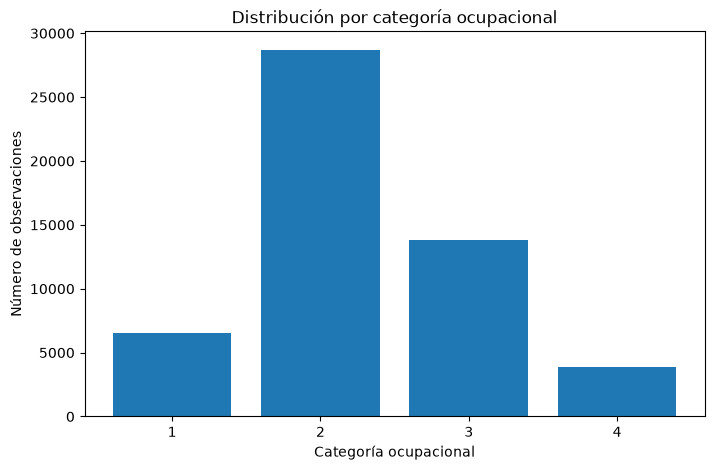

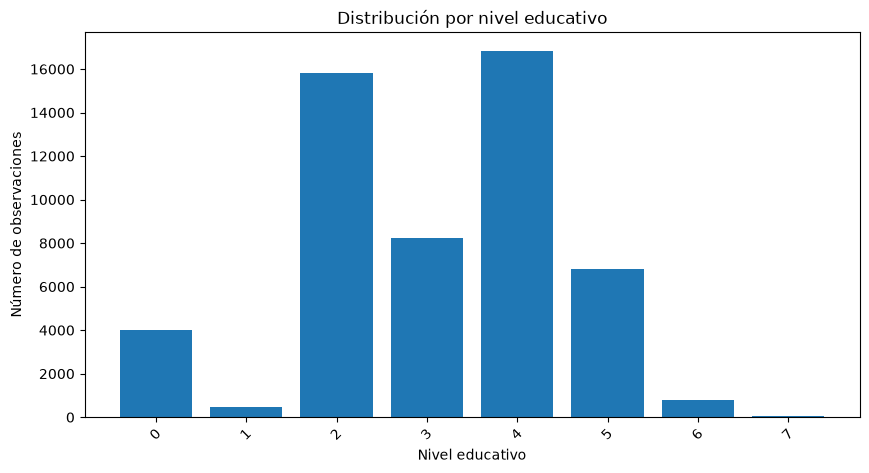

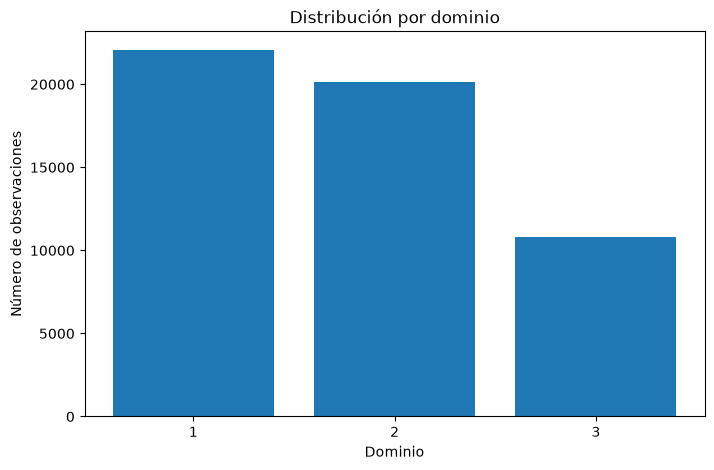

In [53]:
pdf_ocupacion = dist_ocupacion.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_ocupacion["categoria_ocupacional"],
    pdf_ocupacion["count"]
)

plt.title("Distribución por categoría ocupacional")
plt.xlabel("Categoría ocupacional")
plt.ylabel("Número de observaciones")
plt.show()

pdf_educacion = dist_educacion.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    pdf_educacion["nivel_educativo"],
    pdf_educacion["count"]
)

plt.title("Distribución por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45)
plt.show()

pdf_dominio = dist_dominio.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_dominio["dominio"],
    pdf_dominio["count"]
)

plt.title("Distribución por dominio")
plt.xlabel("Dominio")
plt.ylabel("Número de observaciones")
plt.show()

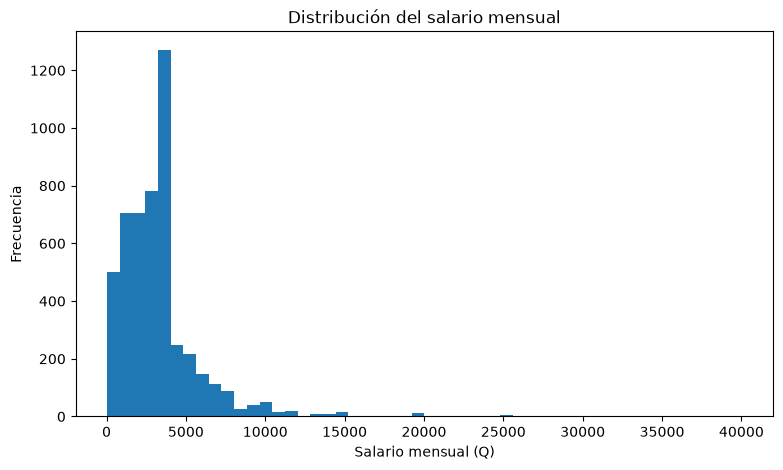

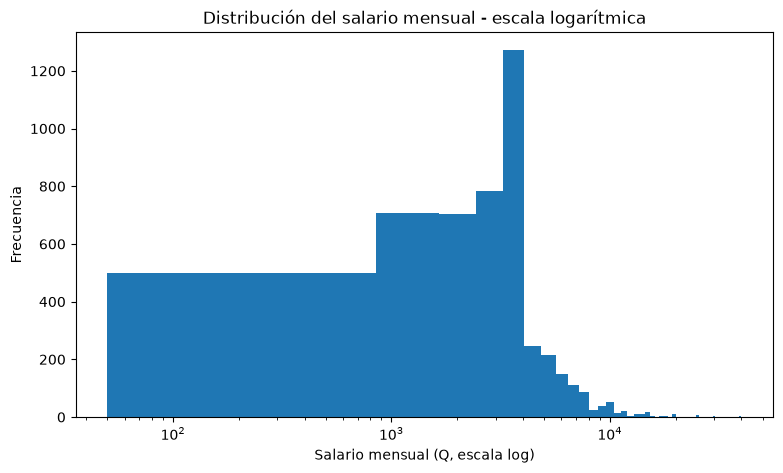

In [54]:
pdf_salario = (
    df_limpio
    .select("salario_mensual")
    .sample(False, 0.15, seed=42)
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.hist(
    pdf_salario["salario_mensual"],
    bins=50
)

plt.title("Distribución del salario mensual")
plt.xlabel("Salario mensual (Q)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(9, 5))

plt.hist(
    pdf_salario["salario_mensual"],
    bins=50
)

plt.xscale("log")

plt.title("Distribución del salario mensual - escala logarítmica")
plt.xlabel("Salario mensual (Q, escala log)")
plt.ylabel("Frecuencia")
plt.show()

+---------------+-----+---------------+
|nivel_educativo|    n|salario_mediano|
+---------------+-----+---------------+
|              0| 3995|         1500.0|
|              1|  459|         2160.0|
|              2|15822|         2200.0|
|              3| 8249|         2800.0|
|              4|16851|         3600.0|
|              5| 6818|         5000.0|
|              6|  771|        10000.0|
|              7|   60|        12000.0|
+---------------+-----+---------------+



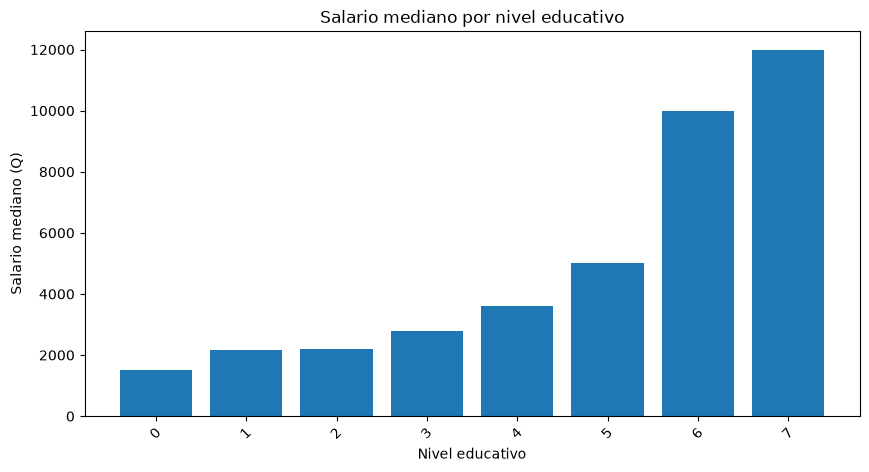

In [55]:
salario_educacion = (
    df_limpio
    .groupBy("nivel_educativo")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("nivel_educativo")
)

salario_educacion.show()

pdf_salario_educacion = salario_educacion.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    pdf_salario_educacion["nivel_educativo"],
    pdf_salario_educacion["salario_mediano"]
)

plt.title("Salario mediano por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario mediano (Q)")
plt.xticks(rotation=45)
plt.show()

+---------------------+-----+---------------+
|categoria_ocupacional|    n|salario_mediano|
+---------------------+-----+---------------+
|                    1| 6575|         5000.0|
|                    2|28702|         3560.0|
|                    3|13842|         1800.0|
|                    4| 3906|         1000.0|
+---------------------+-----+---------------+



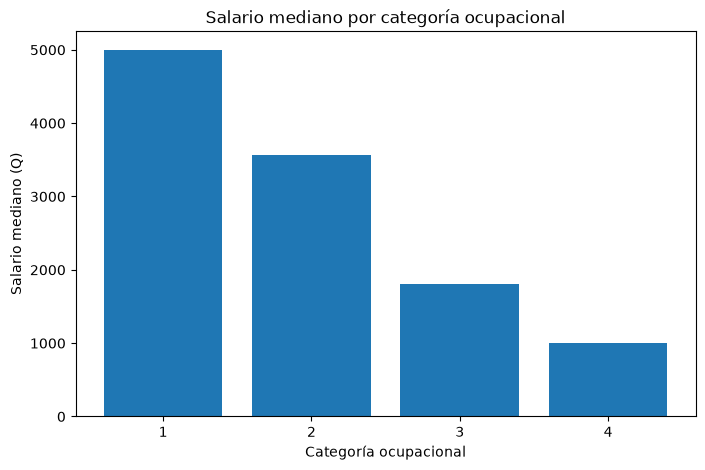

In [56]:
salario_ocupacion = (
    df_limpio
    .groupBy("categoria_ocupacional")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("categoria_ocupacional")
)

salario_ocupacion.show()

pdf_salario_ocupacion = salario_ocupacion.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_salario_ocupacion["categoria_ocupacional"],
    pdf_salario_ocupacion["salario_mediano"]
)

plt.title("Salario mediano por categoría ocupacional")
plt.xlabel("Categoría ocupacional")
plt.ylabel("Salario mediano (Q)")
plt.show()

In [57]:
resumen_trimestre = (
    df_limpio
    .groupBy(
        "periodo_archivo",
        "trimestre_calendario"
    )
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("trimestre_calendario")
)

resumen_trimestre.show()

+---------------+--------------------+-----+---------------+
|periodo_archivo|trimestre_calendario|    n|salario_mediano|
+---------------+--------------------+-----+---------------+
|         2025T1|                   1|13419|         3000.0|
|         2025T2|                   2|13492|         3000.0|
|         2025T3|                   3|13450|         3200.0|
|         2025T4|                   4|12664|         3200.0|
+---------------+--------------------+-----+---------------+



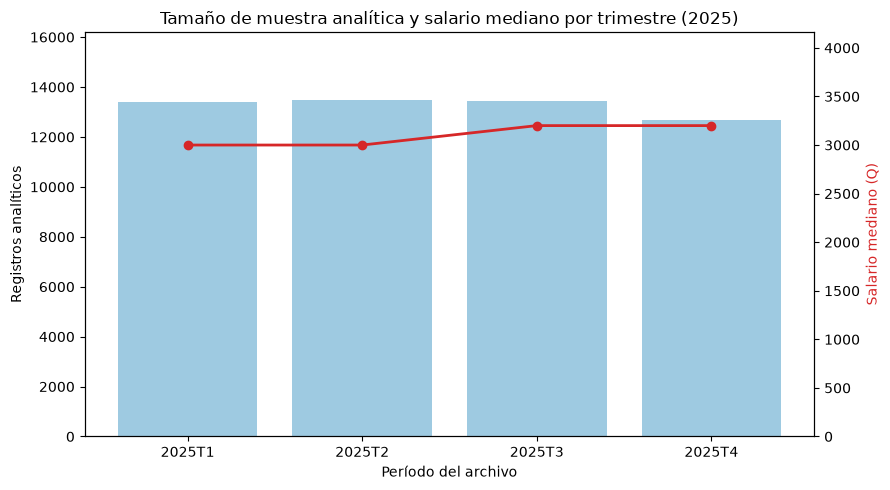

In [58]:
pdf_trimestre = resumen_trimestre.toPandas()

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(pdf_trimestre["periodo_archivo"], pdf_trimestre["n"], color="#9ecae1")
ax1.set_ylabel("Registros analíticos")
ax1.set_xlabel("Período del archivo")
ax1.set_ylim(0, pdf_trimestre["n"].max() * 1.2)

ax2 = ax1.twinx()
ax2.plot(pdf_trimestre["periodo_archivo"], pdf_trimestre["salario_mediano"],
         color="#d62728", marker="o", linewidth=2)
ax2.set_ylabel("Salario mediano (Q)", color="#d62728")
ax2.set_ylim(0, pdf_trimestre["salario_mediano"].max() * 1.3)

plt.title("Tamaño de muestra analítica y salario mediano por trimestre (2025)")
plt.tight_layout()
plt.show()

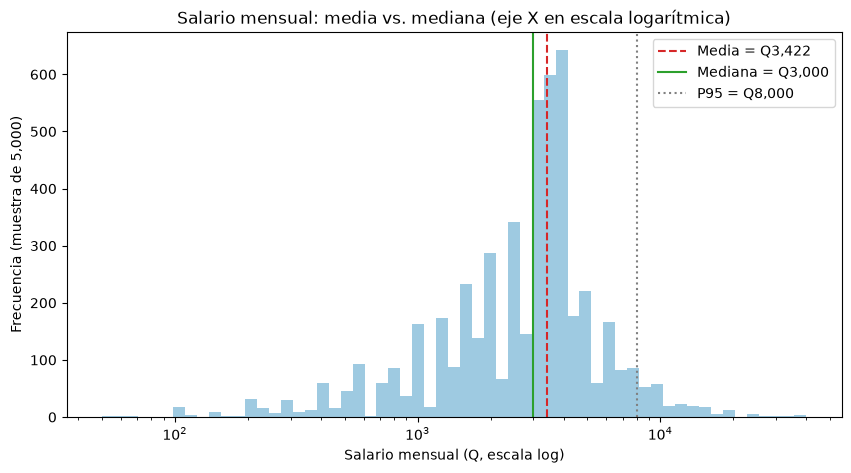

Media y mediana calculadas sobre los 53,025 registros; el histograma usa una muestra.


In [59]:
stats_salario = df_estadisticas.filter(
    F.col("variable") == "salario_mensual"
).first()

plt.figure(figsize=(10, 5))

bins = np.logspace(
    np.log10(pdf_salario["salario_mensual"].min()),
    np.log10(pdf_salario["salario_mensual"].max()),
    60
)

plt.hist(pdf_salario["salario_mensual"], bins=bins, color="#9ecae1")
plt.axvline(stats_salario["media"], color="#d62728", linestyle="--",
            label=f"Media = Q{stats_salario['media']:,.0f}")
plt.axvline(stats_salario["mediana"], color="#2ca02c", linestyle="-",
            label=f"Mediana = Q{stats_salario['mediana']:,.0f}")
plt.axvline(stats_salario["p95"], color="gray", linestyle=":",
            label=f"P95 = Q{stats_salario['p95']:,.0f}")

plt.xscale("log")
plt.title("Salario mensual: media vs. mediana (eje X en escala logarítmica)")
plt.xlabel("Salario mensual (Q, escala log)")
plt.ylabel("Frecuencia (muestra de 5,000)")
plt.legend()
plt.show()

print("Media y mediana calculadas sobre los 53,025 registros; el histograma usa una muestra.")

## Interpretación del análisis exploratorio

La población analítica de 2025 está formada por 53,025 observaciones.

### Distribución de las variables categóricas

La categoría ocupacional 2 es la más frecuente, con 28,702
observaciones, seguida por la categoría 3 con 13,842. Las categorías
1 y 4 presentan 6,575 y 3,906 observaciones, respectivamente. Por lo
tanto, la distribución de los registros entre categorías ocupacionales
no es uniforme.

En nivel educativo, las categorías con mayor cantidad de observaciones
son los niveles 4 (16,851) y 2 (15,822), mientras que los niveles 6 y 7
son considerablemente menos frecuentes.

Respecto al dominio, se observan 22,072 registros en el dominio 1,
20,146 en el dominio 2 y 10,807 en el dominio 3.

### Distribución del salario

El salario mensual presenta una distribución marcadamente asimétrica
hacia la derecha. La mayor concentración de observaciones se encuentra
en los salarios relativamente bajos y medios, mientras existe una cola
hacia valores elevados.

La media salarial es aproximadamente Q3,421.68, mientras que la mediana
es Q3,000. La media superior a la mediana es consistente con la
asimetría positiva observada gráficamente. Además, el percentil 75 es
Q4,000 y el percentil 95 es Q8,000, mientras que el máximo observado
alcanza Q99,000.

Los valores extremos se conservaron en el análisis, de acuerdo con los
criterios establecidos para el laboratorio. La visualización con escala
logarítmica se utilizó únicamente para observar con mayor claridad la
forma de la distribución y no modifica la variable salarial utilizada
en el análisis.

### Edad, antigüedad y jornada laboral

La edad promedio es 35.19 años y la mediana es 33 años. El 50% central
de las observaciones se encuentra aproximadamente entre 24 y 44 años.

La antigüedad presenta una media de 5.56 años y una mediana de 2 años,
lo cual indica también una distribución asimétrica. El percentil 75
corresponde a 7 años y el percentil 95 a 22 años.

Las horas habituales de trabajo presentan una media de 46.31 horas
semanales y una mediana de 45 horas. El 50% central se encuentra entre
40 y 55 horas semanales.

### Salario mediano según educación y categoría ocupacional

Se observa una asociación descriptiva entre nivel educativo y salario
mediano. Los salarios medianos obtenidos para los niveles educativos
0 a 7 fueron Q1,500, Q2,100, Q2,200, Q2,800, Q3,600, Q5,000,
Q10,000 y Q12,000, respectivamente.

Este patrón corresponde a una asociación observada en los datos y no
implica por sí mismo una relación causal entre educación y salario.

También existen diferencias entre categorías ocupacionales. Los
salarios medianos fueron Q5,000 para la categoría 1, Q3,560 para la
categoría 2, Q1,800 para la categoría 3 y Q1,000 para la categoría 4.

### Evolución trimestral

El tamaño de la muestra analítica se mantuvo relativamente estable
durante los primeros tres trimestres: 13,419 observaciones en T1,
13,492 en T2 y 13,450 en T3. En T4 disminuyó a 12,664 observaciones.

El salario mediano fue Q3,000 durante T1 y T2 y Q3,200 durante T3 y T4.
Por tanto, se observa un aumento de Q200 en la mediana entre la primera
y segunda mitad del año dentro de los registros analizados.

## 3. Relaciones entre variables numéricas

In [60]:
variables_corr = [
    "salario_mensual",
    "edad",
    "antiguedad",
    "horas_semanales"
]

assembler_corr = VectorAssembler(
    inputCols=variables_corr,
    outputCol="features_corr"
)

df_corr = assembler_corr.transform(df_limpio)

matriz_corr = (
    Correlation
    .corr(
        df_corr,
        "features_corr",
        "pearson"
    )
    .head()[0]
    .toArray()
)

print(matriz_corr)

[[ 1.          0.14724926  0.17957441  0.07566511]
 [ 0.14724926  1.          0.48671276 -0.10537763]
 [ 0.17957441  0.48671276  1.         -0.06225561]
 [ 0.07566511 -0.10537763 -0.06225561  1.        ]]


,Salario,Edad,Antigüedad,Horas semanales
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas semanales,0.076,-0.105,-0.062,1.000


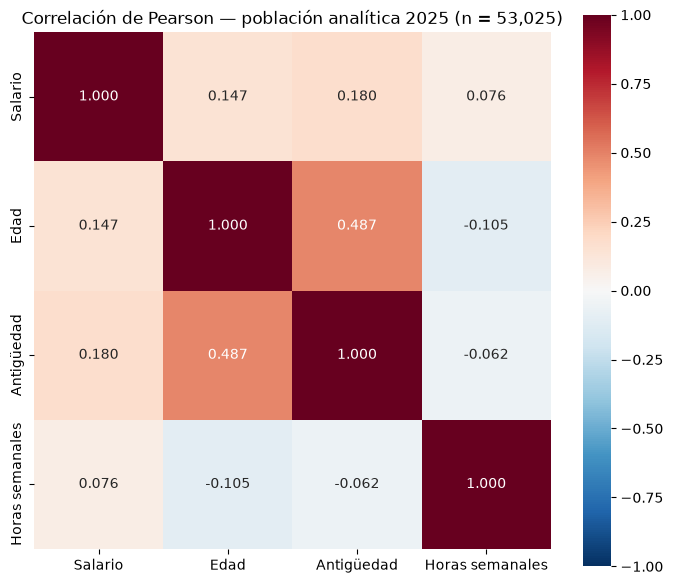

In [61]:
import seaborn as sns

etiquetas_corr = ["Salario", "Edad", "Antigüedad", "Horas semanales"]

pdf_corr = pd.DataFrame(matriz_corr, index=etiquetas_corr, columns=etiquetas_corr)
display(pdf_corr.round(3))

plt.figure(figsize=(7, 6))
sns.heatmap(pdf_corr, annot=True, fmt=".3f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True)
plt.title("Correlación de Pearson — población analítica 2025 (n = 53,025)")
plt.tight_layout()
plt.show()

### Respuestas — Sección 3

**¿Qué variables presentan mayor asociación lineal con el salario?**
La antigüedad (r = 0.180) y la edad (r = 0.147), seguidas de las horas semanales
(r = 0.076). Las tres correlaciones son positivas pero **débiles**. La más alta, elevada al
cuadrado, explica apenas un 3% de la variabilidad del salario. Hay dos razones para esto. Pearson solo
mide relaciones lineales, y el salario puede crecer con la edad y luego estabilizarse. Además,
la cola derecha del salario (hasta Q99,000) pesa mucho en el coeficiente. Como se vio en la
sección 2, el salario se diferencia mucho más por nivel educativo y categoría ocupacional
que por las variables numéricas.

**¿Existe relación entre edad y antigüedad?**
Sí. Es la correlación más fuerte de la matriz: positiva y moderada (r = 0.487). Es lo
esperado, porque la antigüedad no puede superar a la edad y las personas mayores han
tenido más tiempo para acumularla. La relación no es más fuerte porque muchas personas
mayores cambiaron de empleo recientemente y tienen poca antigüedad. Esta asociación implica
cierta redundancia entre ambas variables en el clustering y en la regresión, pero no al nivel
de causar problemas serios de colinealidad.

Las horas semanales tienen una correlación ligeramente negativa con la edad (−0.105) y la
antigüedad (−0.062). Las jornadas más largas se concentran en trabajadores jóvenes y
con menos tiempo en su empleo.

## 4. Segmentación de perfiles mediante KMeans

Se comparan tres conjuntos de variables, todas estandarizadas con `StandardScaler`
(media 0 y desviación 1):

- **A (sin salario):** edad, antigüedad y horas semanales.
- **B (con salario en quetzales):** A + salario mensual.
- **C (con log del salario):** A + log(salario mensual), solo para ver cómo cambia el resultado si se reduce la asimetría.

Para cada conjunto se prueba K = 2, 3, 4 y 5 y se registra el coeficiente de silueta,
la suma de distancias cuadradas intra-cluster (WSSSE) y el tamaño del cluster más pequeño.

In [62]:
from pyspark.ml import Pipeline

CONJUNTOS_CLUSTER = {
    "A_sin_salario": ["edad", "antiguedad", "horas_semanales"],
    "B_con_salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "C_con_log_salario": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}

df_cluster_base = df_2025_final.withColumn(
    "log_salario", F.log(F.col("salario_mensual"))
)

resultados_k = []
modelos_cluster = {}

for nombre, variables in CONJUNTOS_CLUSTER.items():

    pipeline_esc = Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol="features_raw"),
        StandardScaler(inputCol="features_raw", outputCol="features",
                       withMean=True, withStd=True),
    ])
    modelo_esc = pipeline_esc.fit(df_cluster_base)
    datos_esc = modelo_esc.transform(df_cluster_base).cache()

    evaluador_sil = ClusteringEvaluator(featuresCol="features",
                                        predictionCol="cluster",
                                        metricName="silhouette")

    for k in [2, 3, 4, 5]:
        kmeans = KMeans(k=k, seed=42, maxIter=50,
                        featuresCol="features", predictionCol="cluster")
        modelo_k = kmeans.fit(datos_esc)
        pred_k = modelo_k.transform(datos_esc)

        tamanos = modelo_k.summary.clusterSizes
        resultados_k.append({
            "conjunto": nombre,
            "k": k,
            "silueta": evaluador_sil.evaluate(pred_k),
            "wssse": modelo_k.summary.trainingCost,
            "cluster_min_pct": 100 * min(tamanos) / sum(tamanos),
        })
        modelos_cluster[(nombre, k)] = (modelo_esc, modelo_k)

    datos_esc.unpersist()

pdf_k = pd.DataFrame(resultados_k)
display(pdf_k.round(4))

,conjunto,k,silueta,wssse,cluster_min_pct
0,A_sin_salario,2,0.5545,106717.3880,27.5417
1,A_sin_salario,3,0.4716,83607.9721,19.0665
2,A_sin_salario,4,0.4763,64438.3407,12.9448
3,A_sin_salario,5,0.4916,56848.5373,4.9316
4,B_con_salario,2,0.5146,157345.5575,27.0269
5,B_con_salario,3,0.4890,135874.2203,5.4239
6,B_con_salario,4,0.4025,113307.7825,4.9090
7,B_con_salario,5,0.4136,94475.7225,3.9415
8,C_con_log_salario,2,0.4112,171215.4850,22.9439
9,C_con_log_salario,3,0.3128,135120.9851,21.8312


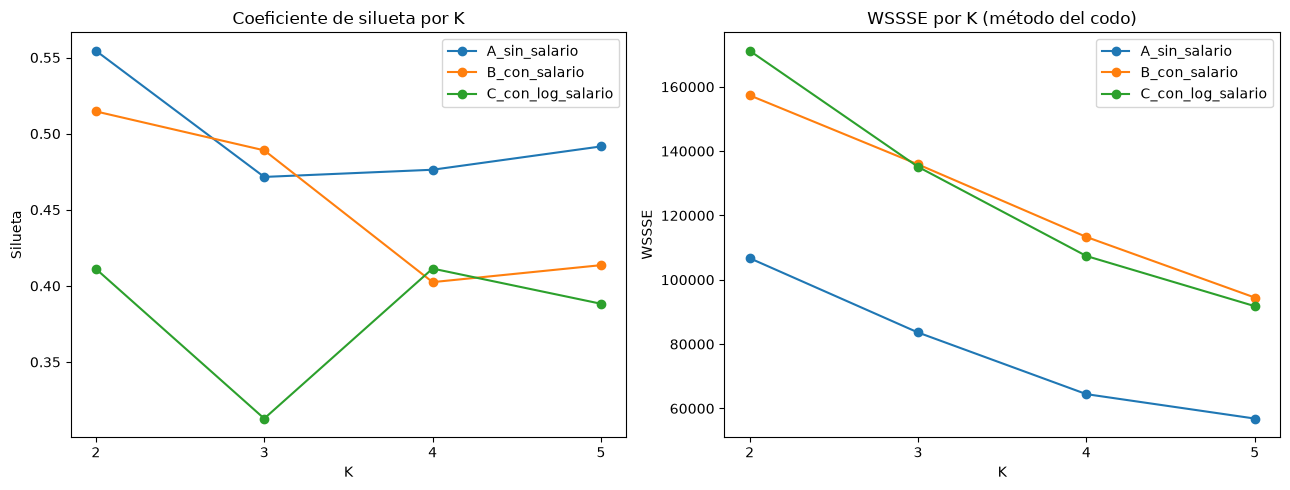

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre, grupo in pdf_k.groupby("conjunto"):
    axes[0].plot(grupo["k"], grupo["silueta"], marker="o", label=nombre)
    axes[1].plot(grupo["k"], grupo["wssse"], marker="o", label=nombre)

axes[0].set_title("Coeficiente de silueta por K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silueta")
axes[0].set_xticks([2, 3, 4, 5])
axes[0].legend()

axes[1].set_title("WSSSE por K (método del codo)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("WSSSE")
axes[1].set_xticks([2, 3, 4, 5])
axes[1].legend()

plt.tight_layout()
plt.show()

### Selección de variables y de K

**¿Vale la pena incluir el salario? No.** Con el salario en quetzales (conjunto B), los
salarios extremos dominan la distancia euclidiana y forman clusters muy pequeños: con K = 3
aparece un grupo de apenas 5.4% de los registros, definido casi solo por ingresos altos.
Con el logaritmo del salario (conjunto C), la silueta empeora para todos los K (0.31–0.41).
Además, el salario es la variable que se busca predecir en la segunda parte. Por eso es más útil
definir los perfiles con características laborales y demográficas y *después* comparar
cuánto gana cada perfil.

**Criterio del grupo para elegir K.** Buscamos una silueta cercana o superior a 0.45, que
todos los clusters tengan al menos el 10% de los registros y que los perfiles se puedan
interpretar con claridad. Con esos criterios elegimos el **conjunto A con K = 4**:

| K | Silueta | WSSSE | Cluster más pequeño | Evaluación |
|---|---|---|---|---|
| 2 | 0.555 | 106,717 | 27.5% | Mejor silueta, pero solo separa jóvenes de mayores; demasiado general |
| 3 | 0.472 | 83,608 | 19.1% | Aceptable |
| **4** | **0.476** | **64,438** | **12.9%** | Silueta similar a K = 3, la WSSSE baja 23% y aparecen 4 perfiles distintos |
| 5 | 0.492 | 56,849 | 4.9% | Crea un cluster demasiado pequeño para describirlo con confianza |

In [64]:
CONJUNTO_FINAL = "A_sin_salario"
K_FINAL = 4

modelo_esc_final, modelo_km_final = modelos_cluster[(CONJUNTO_FINAL, K_FINAL)]

df_clusters = modelo_km_final.transform(
    modelo_esc_final.transform(df_cluster_base)
).drop("features_raw", "features").cache()

centros = pd.DataFrame(
    modelo_km_final.clusterCenters(),
    columns=CONJUNTOS_CLUSTER[CONJUNTO_FINAL]
)
centros.index.name = "cluster"
print("Centroides (unidades estandarizadas):")
display(centros.round(2))

Centroides (unidades estandarizadas):


,edad,antiguedad,horas_semanales
cluster,,,
0,1.09,2.13,-0.28
1,-0.69,-0.40,-0.29
2,0.98,-0.19,-0.37
3,-0.34,-0.26,1.53


In [65]:
from pyspark.sql.window import Window

perfil_clusters = (
    df_clusters
    .groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        F.round(F.mean("edad"), 1).alias("edad_media"),
        F.round(F.mean("antiguedad"), 1).alias("antig_media"),
        F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
        F.percentile_approx("salario_mensual", 0.5).alias("salario_mediano"),
        F.round(F.mean("salario_mensual"), 0).alias("salario_medio"),
        F.round(100 * F.mean(F.when(F.col("nivel_educativo").isin("5", "6", "7"), 1).otherwise(0)), 1).alias("pct_superior"),
        F.round(100 * F.mean(F.when(F.col("categoria_ocupacional") == "1", 1).otherwise(0)), 1).alias("pct_gobierno"),
        F.round(100 * F.mean(F.when(F.col("categoria_ocupacional") == "3", 1).otherwise(0)), 1).alias("pct_jornalero"),
        F.round(100 * F.mean(F.when(F.col("categoria_ocupacional") == "4", 1).otherwise(0)), 1).alias("pct_domestico"),
        F.round(100 * F.mean(F.when(F.col("dominio") == "3", 1).otherwise(0)), 1).alias("pct_rural"),
    )
    .withColumn("pct_registros", F.round(100 * F.col("n") / F.sum("n").over(Window.partitionBy()), 1))
    .orderBy("cluster")
)

pdf_perfil = perfil_clusters.toPandas()
display(pdf_perfil)

,cluster,n,edad_media,antig_media,horas_media,salario_mediano,salario_medio,pct_superior,pct_gobierno,pct_jornalero,pct_domestico,pct_rural,pct_registros
0,0,6864,49.9,22.2,41.1,3800.0,4680.0,24.6,31.4,22.3,5.9,16.7,12.9
1,1,24511,25.8,2.4,41.0,3000.0,3075.0,14.0,7.8,29.2,5.8,21.8,46.2
2,2,12745,48.5,4.1,39.4,3000.0,3535.0,15.9,14.1,27.3,12.3,18.1,24.0
3,3,8905,30.6,3.5,74.8,3000.0,3244.0,5.7,8.0,18.8,5.8,22.5,16.8


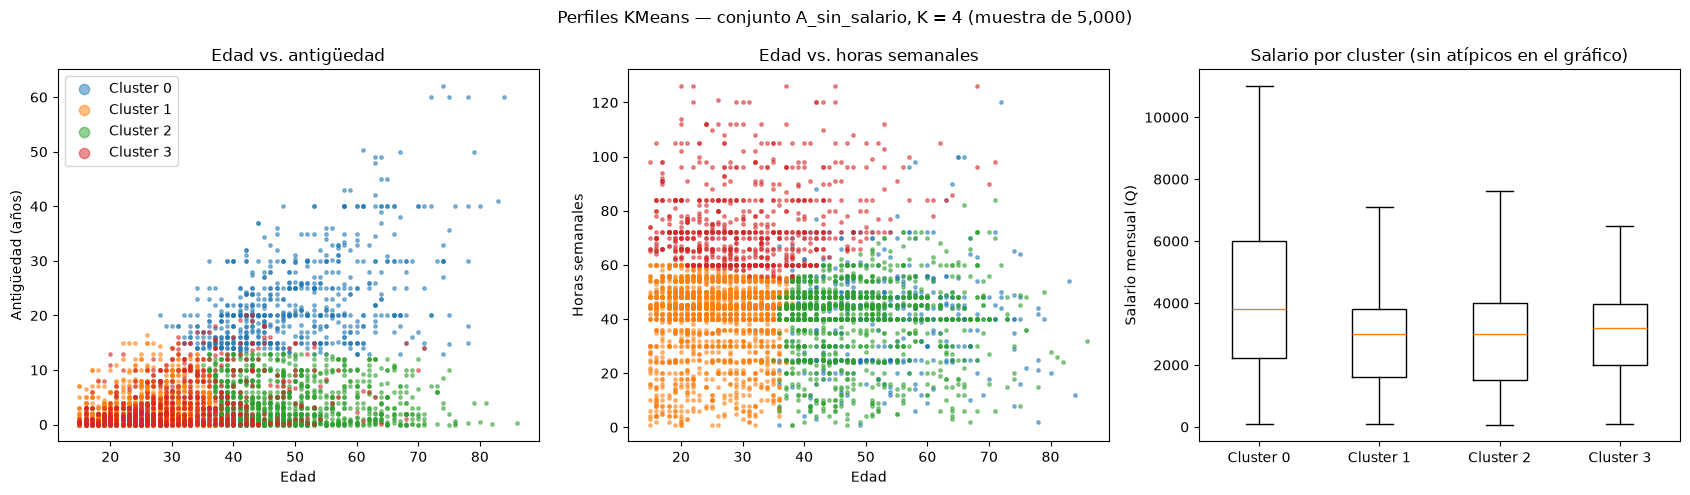

In [66]:
pdf_cluster_muestra = (
    df_clusters
    .select("edad", "antiguedad", "horas_semanales", "salario_mensual", "cluster")
    .sample(False, 0.15, seed=42)
    .limit(5000)
    .toPandas()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for c, grupo in pdf_cluster_muestra.groupby("cluster"):
    axes[0].scatter(grupo["edad"], grupo["antiguedad"], s=6, alpha=0.5, label=f"Cluster {c}")
    axes[1].scatter(grupo["edad"], grupo["horas_semanales"], s=6, alpha=0.5, label=f"Cluster {c}")

axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Antigüedad (años)")
axes[0].set_title("Edad vs. antigüedad")
axes[0].legend(markerscale=3)

axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Horas semanales")
axes[1].set_title("Edad vs. horas semanales")

orden = sorted(pdf_cluster_muestra["cluster"].unique())
axes[2].boxplot(
    [pdf_cluster_muestra.loc[pdf_cluster_muestra["cluster"] == c, "salario_mensual"] for c in orden],
    tick_labels=[f"Cluster {c}" for c in orden],
    showfliers=False
)
axes[2].set_ylabel("Salario mensual (Q)")
axes[2].set_title("Salario por cluster (sin atípicos en el gráfico)")

plt.suptitle(f"Perfiles KMeans — conjunto {CONJUNTO_FINAL}, K = {K_FINAL} (muestra de 5,000)")
plt.tight_layout()
plt.show()

### Descripción de los perfiles (conjunto A, K = 4)

| Cluster | % registros | Perfil | Rasgos principales |
|---|---|---|---|
| 0 | 12.9% | **Trabajadores consolidados** | 50 años y 22 años de antigüedad en promedio. Tienen el salario mediano más alto (Q3,800; media Q4,680). El 31% trabaja en el gobierno y el 25% tiene educación superior |
| 1 | 46.2% | **Jóvenes al inicio de su carrera** | 26 años, 2.4 años de antigüedad y jornada estándar (41 h). Salario mediano de Q3,000. Es el grupo más grande |
| 2 | 24.0% | **Adultos con poca antigüedad** | 49 años pero solo 4 años en su empleo actual: cambiaron de trabajo o se reinsertaron. El 12% está en servicio doméstico, la proporción más alta. Salario mediano de Q3,000 |
| 3 | 16.8% | **Jornadas extendidas** | 31 años y **75 horas semanales**, casi el doble que el resto. Ganan la misma mediana (Q3,000), así que su ingreso por hora es mucho menor. Solo el 6% tiene educación superior y el 23% vive en zona rural |

**Hallazgos.** La antigüedad es lo que más diferencia al grupo con mejores salarios.
Tener edad avanzada no basta: el cluster 2 tiene casi la misma edad que el 0, pero gana
menos. Las jornadas largas no se traducen en mejores salarios mensuales. Tres de los
cuatro perfiles comparten la misma mediana salarial, lo que confirma que la edad, la antigüedad
y las horas por sí solas separan poco el salario (sección 3). Esto anticipa que para
predecirlo serán necesarias las variables categóricas. Los perfiles describen los registros
analizados sin ponderar y no son estimaciones poblacionales.

# Modelado supervisado para predicción

## 5. Pipeline de regresión lineal

**Esquema de datos:**

| Conjunto | Períodos | Uso |
|---|---|---|
| Entrenamiento | 2025T1, 2025T2, 2025T3 | Ajuste de todos los componentes del pipeline |
| Validación | 2025T4 | Selección de la configuración (menor RMSE) |
| Entrenamiento final | 2025T1–2025T4 | Reajuste de la configuración elegida (sección 7) |
| Prueba | 2026T1 | Evaluación final, se usa una sola vez |

Se utilizan exactamente seis predictores: `edad`, `antiguedad`, `horas_semanales`,
`nivel_educativo`, `categoria_ocupacional` y `dominio`. El objetivo es `salario_mensual`
en quetzales, sin transformaciones ni recortes.

**Modelo de referencia:** predecir para todos los registros el salario medio del
conjunto de entrenamiento. Cualquier modelo útil debe superarlo.

In [67]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import PipelineModel

OBJETIVO = "salario_mensual"
NUMERICAS = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
SEMILLA = 42
MODELOS_DIR = "./modelos"
os.makedirs(MODELOS_DIR, exist_ok=True)

columnas_modelo = CLAVE + [OBJETIVO] + NUMERICAS + CATEGORICAS

train = (
    df_2025_final
    .filter(F.col("trimestre_calendario").isin(1, 2, 3))
    .select(*columnas_modelo)
    .cache()
)
valid = (
    df_2025_final
    .filter(F.col("trimestre_calendario") == 4)
    .select(*columnas_modelo)
    .cache()
)

print(f"Entrenamiento (2025T1–T3): {train.count():,}")
print(f"Validación    (2025T4):    {valid.count():,}")

Entrenamiento (2025T1–T3): 40,361


Validación    (2025T4):    12,664


In [68]:
def etapas_preprocesamiento():
    """StringIndexer + OneHotEncoder para categóricas y VectorAssembler.

    Con frequencyAsc la categoría más frecuente queda al final y dropLast la
    omite: esa es la categoría de referencia de la regresión lineal. Las
    categorías ya fueron validadas contra el diccionario, así que un código
    no visto en entrenamiento detiene la ejecución en lugar de ocultarse.
    """
    indexadores = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                      handleInvalid="error", stringOrderType="frequencyAsc")
        for c in CATEGORICAS
    ]
    codificador = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in CATEGORICAS],
        outputCols=[f"{c}_ohe" for c in CATEGORICAS],
        dropLast=True,
    )
    ensamblador = VectorAssembler(
        inputCols=NUMERICAS + [f"{c}_ohe" for c in CATEGORICAS],
        outputCol="features",
    )
    return indexadores + [codificador, ensamblador]


def calcular_metricas(df, col_pred="prediction", col_real=OBJETIVO):
    evaluador = RegressionEvaluator(labelCol=col_real, predictionCol=col_pred)
    return {
        "MAE": evaluador.evaluate(df, {evaluador.metricName: "mae"}),
        "RMSE": evaluador.evaluate(df, {evaluador.metricName: "rmse"}),
        "R2": evaluador.evaluate(df, {evaluador.metricName: "r2"}),
    }


media_train = train.agg(F.mean(OBJETIVO)).first()[0]
mediana_train = train.approxQuantile(OBJETIVO, [0.5], 0.0)[0]

metricas_ref = calcular_metricas(valid.withColumn("prediction", F.lit(media_train)))
metricas_ref_mediana = calcular_metricas(valid.withColumn("prediction", F.lit(mediana_train)))

print(f"Salario medio de entrenamiento:   Q{media_train:,.2f}")
print(f"Salario mediano de entrenamiento: Q{mediana_train:,.2f}")
display(pd.DataFrame(
    [metricas_ref, metricas_ref_mediana],
    index=["Referencia: media", "Referencia: mediana"]
).round(3))

Salario medio de entrenamiento:   Q3,383.12
Salario mediano de entrenamiento: Q3,000.00


,MAE,RMSE,R2
Referencia: media,1672.503,2889.571,-0.003
Referencia: mediana,1670.390,2936.004,-0.036


### Configuraciones de regularización

La estandarización se realiza con la opción interna `standardization=True` de
`LinearRegression`, así que no se añade `StandardScaler`. Los coeficientes que devuelve
Spark quedan en la escala original. Se prueban:

| Config | regParam (λ) | elasticNetParam (α) | Tipo |
|---|---|---|---|
| LR-1 | 0.0 | 0.0 | Mínimos cuadrados sin regularizar |
| LR-2 | 0.01 | 0.0 | Ridge (L2) débil |
| LR-3 | 0.1 | 0.0 | Ridge (L2) moderada |
| LR-4 | 1.0 | 0.0 | Ridge (L2) fuerte |
| LR-5 | 0.01 | 1.0 | Lasso (L1) |
| LR-6 | 0.1 | 0.5 | Elastic Net |

In [69]:
CONFIGS_LR = [
    {"nombre": "LR-1", "regParam": 0.0,  "elasticNetParam": 0.0},
    {"nombre": "LR-2", "regParam": 0.01, "elasticNetParam": 0.0},
    {"nombre": "LR-3", "regParam": 0.1,  "elasticNetParam": 0.0},
    {"nombre": "LR-4", "regParam": 1.0,  "elasticNetParam": 0.0},
    {"nombre": "LR-5", "regParam": 0.01, "elasticNetParam": 1.0},
    {"nombre": "LR-6", "regParam": 0.1,  "elasticNetParam": 0.5},
]


def pipeline_lr(regParam, elasticNetParam):
    lr = LinearRegression(
        featuresCol="features", labelCol=OBJETIVO, predictionCol="prediction",
        regParam=regParam, elasticNetParam=elasticNetParam,
        standardization=True, maxIter=100,
    )
    return Pipeline(stages=etapas_preprocesamiento() + [lr])


resultados_lr = []
modelos_lr = {}

for cfg in CONFIGS_LR:
    modelo = pipeline_lr(cfg["regParam"], cfg["elasticNetParam"]).fit(train)
    m_train = calcular_metricas(modelo.transform(train))
    m_valid = calcular_metricas(modelo.transform(valid))
    modelos_lr[cfg["nombre"]] = modelo
    resultados_lr.append({
        **cfg,
        "MAE_train": m_train["MAE"], "RMSE_train": m_train["RMSE"], "R2_train": m_train["R2"],
        "MAE_valid": m_valid["MAE"], "RMSE_valid": m_valid["RMSE"], "R2_valid": m_valid["R2"],
    })

pdf_lr = pd.DataFrame(resultados_lr)
display(pdf_lr.round(4))

mejor_lr = pdf_lr.loc[pdf_lr["RMSE_valid"].idxmin()]
print(f"Mejor configuración LR (menor RMSE de validación): {mejor_lr['nombre']} "
      f"(regParam={mejor_lr['regParam']}, elasticNetParam={mejor_lr['elasticNetParam']})")

,nombre,regParam,elasticNetParam,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,LR-1,0.00,0.0,1237.7905,2245.2927,0.4032,1210.1375,2186.4196,0.4257
1,LR-2,0.01,0.0,1237.7900,2245.2927,0.4032,1210.1370,2186.4197,0.4257
2,LR-3,0.10,0.0,1237.7861,2245.2927,0.4032,1210.1323,2186.4210,0.4257
3,LR-4,1.00,0.0,1237.7467,2245.2927,0.4032,1210.0857,2186.4335,0.4257
4,LR-5,0.01,1.0,1237.7863,2245.2927,0.4032,1210.1325,2186.4203,0.4257
5,LR-6,0.10,0.5,1237.7678,2245.2927,0.4032,1210.1101,2186.4240,0.4257


Mejor configuración LR (menor RMSE de validación): LR-1 (regParam=0.0, elasticNetParam=0.0)


In [70]:
modelo_lr_valid = modelos_lr[mejor_lr["nombre"]]
modelo_lr_valid.write().overwrite().save(f"{MODELOS_DIR}/lr_mejor_validacion")

pred_valid_lr = modelo_lr_valid.transform(valid).cache()
metricas_valid_lr = calcular_metricas(pred_valid_lr)

comparacion_valid = pd.DataFrame(
    [metricas_ref, metricas_valid_lr],
    index=["Referencia (media)", f"Regresión lineal ({mejor_lr['nombre']})"]
)
display(comparacion_valid.round(3))

# Coeficientes con el nombre de cada predictor
attrs = pred_valid_lr.schema["features"].metadata["ml_attr"]["attrs"]
nombres = [a["name"] for a in sorted(
    [a for grupo in attrs.values() for a in grupo], key=lambda a: a["idx"]
)]
coefs = modelo_lr_valid.stages[-1].coefficients.toArray()

pdf_coef = pd.DataFrame({"predictor": nombres, "coeficiente_Q": coefs})
print(f"Intercepto: Q{modelo_lr_valid.stages[-1].intercept:,.2f}")

print("Categoría de referencia (omitida por dropLast) = la más frecuente de cada variable:")
for i, c in enumerate(CATEGORICAS):
    referencia = modelo_lr_valid.stages[i].labels[-1]
    print(f"  {c}: {referencia} ({ETIQUETAS[c][referencia]})")

pdf_coef["etiqueta"] = [
    ETIQUETAS[c][n.split("_ohe_")[1]] if "_ohe_" in n else ""
    for n in pdf_coef["predictor"]
    for c in [n.split("_ohe_")[0]]
]
display(pdf_coef.round(2))

,MAE,RMSE,R2
Referencia (media),1672.503,2889.571,-0.003
Regresión lineal (LR-1),1210.137,2186.420,0.426


Intercepto: Q2,457.97
Categoría de referencia (omitida por dropLast) = la más frecuente de cada variable:
  nivel_educativo: 4 (Diversificado)
  categoria_ocupacional: 2 (Empresa privada)
  dominio: 1 (Urbano metropolitano)


,predictor,coeficiente_Q,etiqueta
0,edad,20.43,
1,antiguedad,23.37,
2,horas_semanales,16.17,
3,nivel_educativo_ohe_7,8619.70,Doctorado
4,nivel_educativo_ohe_1,-1049.07,Preprimaria
5,nivel_educativo_ohe_6,6780.56,Maestría
6,nivel_educativo_ohe_0,-1333.40,Ninguno
7,nivel_educativo_ohe_5,1694.39,Superior
8,nivel_educativo_ohe_3,-631.22,Básico
9,nivel_educativo_ohe_2,-836.43,Primaria


### Interpretación — Regresión lineal

**Frente al modelo de referencia.** Si se predice siempre el salario medio de
entrenamiento (Q3,383), en validación se obtiene MAE = Q1,673, RMSE = Q2,890 y R² ≈ 0. La
regresión lineal baja el MAE a **Q1,210 (−28%)** y el RMSE a **Q2,186 (−24%)**, con
**R² = 0.426**. Los seis predictores explican cerca del 43% de la variabilidad del salario;
el 57% restante depende de factores que no están en el modelo, como el tipo de
ocupación, la rama de actividad, la empresa o el departamento.

**Regularización.** Las seis configuraciones dan prácticamente el mismo resultado: el RMSE
de validación varía menos de Q0.02 entre ellas. Hay 15 coeficientes y más de 40,000
registros, y el R² de entrenamiento (0.403) no supera al de validación (0.426). Es decir,
el modelo no sobreajusta, así que penalizar los coeficientes no aporta nada. Por la regla
establecida (menor RMSE de validación) se elige **LR-1 (λ = 0, sin regularización)**,
aunque la diferencia con las demás es despreciable.

**Coeficientes (en quetzales mensuales).** La categoría de referencia es una persona con
diversificado, empleada de empresa privada, en el dominio urbano metropolitano:

- Cada año adicional de **edad** se asocia con +Q20, cada año de **antigüedad** con +Q23 y
  cada **hora semanal** adicional con +Q16, manteniendo lo demás constante.
- **Educación** (frente a diversificado): superior +Q1,694, maestría +Q6,781 y doctorado
  +Q8,620. Ninguna educación −Q1,333 y primaria −Q836. Es el factor con mayor efecto.
- **Categoría ocupacional** (frente a empresa privada): gobierno +Q1,174, jornalero o peón
  −Q858 y servicio doméstico −Q1,665.
- **Dominio** (frente a urbano metropolitano): resto urbano −Q559 y rural −Q568.
- El intercepto (Q2,458) corresponde a edad, antigüedad y horas iguales a cero, así que
  no tiene interpretación directa.

Estos coeficientes son **asociaciones** en los registros analizados. No son efectos causales
ni indican cuánto *debería* ganar una persona.

**Limitaciones.** El modelo es aditivo y lineal: supone que un año más de antigüedad
vale lo mismo en todos los niveles educativos y sectores. Tampoco puede reproducir la cola
derecha del salario, por lo que los salarios altos quedan subestimados (ver sección 8).

## 6. Pipeline de Random Forest

Se usan los mismos conjuntos de entrenamiento (2025T1–T3) y validación (2025T4) y las mismas
etapas de preprocesamiento, sin estandarización. La semilla es fija (`seed=42`).

| Config | numTrees | maxDepth |
|---|---|---|
| RF-1 | 50 | 5 |
| RF-2 | 100 | 5 |
| RF-3 | 50 | 10 |
| RF-4 | 100 | 10 |

In [71]:
CONFIGS_RF = [
    {"nombre": "RF-1", "numTrees": 50,  "maxDepth": 5},
    {"nombre": "RF-2", "numTrees": 100, "maxDepth": 5},
    {"nombre": "RF-3", "numTrees": 50,  "maxDepth": 10},
    {"nombre": "RF-4", "numTrees": 100, "maxDepth": 10},
]


def pipeline_rf(numTrees, maxDepth):
    rf = RandomForestRegressor(
        featuresCol="features", labelCol=OBJETIVO, predictionCol="prediction",
        numTrees=numTrees, maxDepth=maxDepth, seed=SEMILLA,
    )
    return Pipeline(stages=etapas_preprocesamiento() + [rf])


resultados_rf = []
modelos_rf = {}

for cfg in CONFIGS_RF:
    modelo = pipeline_rf(cfg["numTrees"], cfg["maxDepth"]).fit(train)
    m_train = calcular_metricas(modelo.transform(train))
    m_valid = calcular_metricas(modelo.transform(valid))
    modelos_rf[cfg["nombre"]] = modelo
    resultados_rf.append({
        **cfg,
        "MAE_train": m_train["MAE"], "RMSE_train": m_train["RMSE"], "R2_train": m_train["R2"],
        "MAE_valid": m_valid["MAE"], "RMSE_valid": m_valid["RMSE"], "R2_valid": m_valid["R2"],
    })

pdf_rf = pd.DataFrame(resultados_rf)
display(pdf_rf.round(4))

mejor_rf = pdf_rf.loc[pdf_rf["RMSE_valid"].idxmin()]
print(f"Mejor configuración RF (menor RMSE de validación): {mejor_rf['nombre']} "
      f"(numTrees={int(mejor_rf['numTrees'])}, maxDepth={int(mejor_rf['maxDepth'])})")

,nombre,numTrees,maxDepth,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,RF-1,50,5,1206.4439,2219.0225,0.4170,1192.8320,2192.3469,0.4226
1,RF-2,100,5,1209.7510,2215.8067,0.4187,1194.5174,2185.0594,0.4264
2,RF-3,50,10,1080.3069,1934.7444,0.5568,1087.3193,2022.0601,0.5088
3,RF-4,100,10,1077.1149,1945.3433,0.5520,1083.0530,2009.7332,0.5147


Mejor configuración RF (menor RMSE de validación): RF-4 (numTrees=100, maxDepth=10)


Comparación en validación (2025T4):


,MAE,RMSE,R2
Referencia (media),1672.503,2889.571,-0.003
Regresión lineal (LR-1),1210.137,2186.420,0.426
Random Forest (RF-4),1083.053,2009.733,0.515


,predictor,importancia
5,nivel_educativo_ohe_6,0.1971
7,nivel_educativo_ohe_5,0.1432
11,categoria_ocupacional_ohe_1,0.1181
2,horas_semanales,0.1102
12,categoria_ocupacional_ohe_3,0.1049
0,edad,0.1009
1,antiguedad,0.0780
10,categoria_ocupacional_ohe_4,0.0550
9,nivel_educativo_ohe_2,0.0310
3,nivel_educativo_ohe_7,0.0240


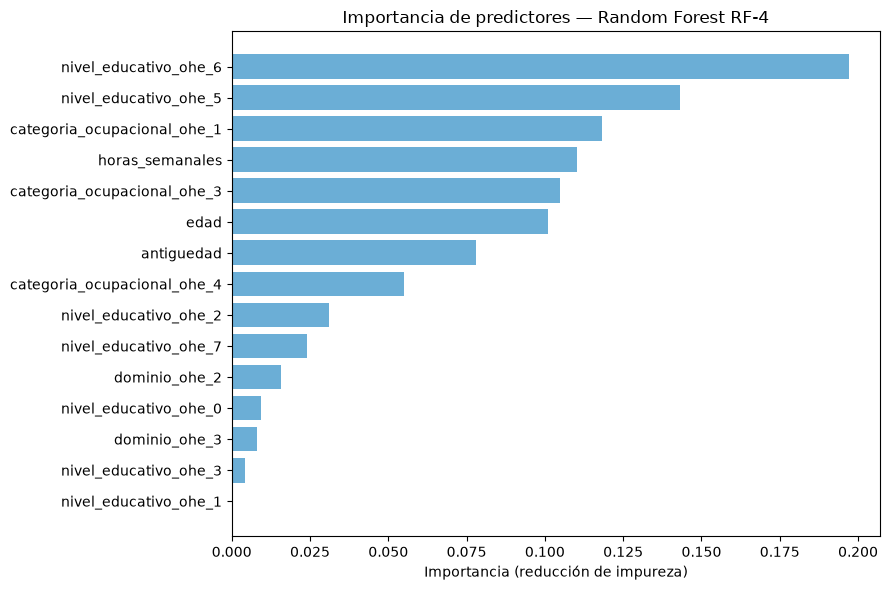

In [72]:
modelo_rf_valid = modelos_rf[mejor_rf["nombre"]]
modelo_rf_valid.write().overwrite().save(f"{MODELOS_DIR}/rf_mejor_validacion")

metricas_valid_rf = calcular_metricas(modelo_rf_valid.transform(valid))

comparacion_valid = pd.DataFrame(
    [metricas_ref, metricas_valid_lr, metricas_valid_rf],
    index=["Referencia (media)",
           f"Regresión lineal ({mejor_lr['nombre']})",
           f"Random Forest ({mejor_rf['nombre']})"]
)
print("Comparación en validación (2025T4):")
display(comparacion_valid.round(3))

importancias = modelo_rf_valid.stages[-1].featureImportances.toArray()
pdf_imp = (
    pd.DataFrame({"predictor": nombres, "importancia": importancias})
    .sort_values("importancia", ascending=False)
)
display(pdf_imp.round(4))

plt.figure(figsize=(9, 6))
plt.barh(pdf_imp["predictor"][::-1], pdf_imp["importancia"][::-1], color="#6baed6")
plt.title(f"Importancia de predictores — Random Forest {mejor_rf['nombre']}")
plt.xlabel("Importancia (reducción de impureza)")
plt.tight_layout()
plt.show()

### Interpretación — Random Forest

- **Profundidad 5** no alcanza: R² ≈ 0.42, igual que la regresión lineal.
- **Profundidad 10** sube el R² a 0.51. Pasar de 50 a 100 árboles mejora poco el RMSE (Q2,022 → Q2,010).
- **Elegido: RF-4** (100 árboles, profundidad 10), con el menor RMSE de validación. El R² de entrenamiento (0.552) y el de validación (0.515) son cercanos, así que no hay sobreajuste fuerte.

| Validación 2025T4 | MAE | RMSE | R² |
|---|---|---|---|
| Referencia (media) | Q1,673 | Q2,890 | 0.00 |
| Regresión lineal | Q1,210 | Q2,186 | 0.426 |
| **Random Forest** | **Q1,083** | **Q2,010** | **0.515** |

**Gana Random Forest:** reduce el RMSE un 8% frente a la regresión lineal y un 30% frente a la referencia.

**¿Por qué?** La regresión lineal suma efectos fijos. Random Forest capta no linealidades
(el salario deja de subir con la edad) e interacciones (el premio por educación depende del
sector) sin tener que especificarlas. Su límite: predice promedios de hojas y no puede ir más allá
de los valores que vio.

**Importancia:** maestría (0.20), superior (0.14), gobierno (0.12), horas (0.11),
jornalero (0.10) y edad (0.10). La educación y la categoría ocupacional explican casi todo;
el dominio aporta poco.

## 7. Entrenamiento final y evaluación en 2026

Con una configuración elegida por algoritmo, cada pipeline se reajusta desde cero con
los cuatro trimestres de 2025 (T1–T4). Después se predice el primer trimestre de 2026, que
fue preparado con las mismas reglas (función `preparar_poblacion`). Ambos modelos se evalúan
sobre exactamente los mismos registros, unidos por la clave
`periodo_archivo + NUM_HOGAR + NUM_PERSONA`.

In [73]:
train_final = df_2025_final.select(*columnas_modelo).cache()
test = df_2026_final.select(*columnas_modelo).cache()

print(f"Entrenamiento final (2025T1–T4): {train_final.count():,}")
print(f"Prueba (2026T1):                 {test.count():,}")

modelo_lr_final = pipeline_lr(
    float(mejor_lr["regParam"]), float(mejor_lr["elasticNetParam"])
).fit(train_final)

modelo_rf_final = pipeline_rf(
    int(mejor_rf["numTrees"]), int(mejor_rf["maxDepth"])
).fit(train_final)

modelo_lr_final.write().overwrite().save(f"{MODELOS_DIR}/lr_final_2025")
modelo_rf_final.write().overwrite().save(f"{MODELOS_DIR}/rf_final_2025")

media_2025 = train_final.agg(F.mean(OBJETIVO)).first()[0]

resultados_test = (
    modelo_lr_final.transform(test)
    .select(*CLAVE, OBJETIVO, *NUMERICAS, *CATEGORICAS,
            F.col("prediction").alias("pred_lr"))
    .join(
        modelo_rf_final.transform(test)
        .select(*CLAVE, F.col("prediction").alias("pred_rf")),
        on=CLAVE, how="inner"
    )
    .withColumn("pred_ref", F.lit(media_2025))
    .withColumn("residuo_lr", F.col(OBJETIVO) - F.col("pred_lr"))
    .withColumn("residuo_rf", F.col(OBJETIVO) - F.col("pred_rf"))
    .cache()
)

n_test = test.count()
n_eval = resultados_test.count()
print(f"Registros evaluados por ambos modelos: {n_eval:,} de {n_test:,}")
assert n_eval == n_test

Entrenamiento final (2025T1–T4): 53,025
Prueba (2026T1):                 13,258


Registros evaluados por ambos modelos: 13,258 de 13,258


Métricas en prueba (2026T1):


,MAE,RMSE,R2
Referencia (media 2025),1718.086,2871.421,-0.003
Regresión lineal (LR-1),1240.711,2163.752,0.431
Random Forest (RF-4),1113.698,1983.584,0.522


Validación 2025T4                  Prueba 2026T1  \
                                      MAE      RMSE     R2           MAE   
Referencia (media)               1672.503  2889.571 -0.003      1718.086   
Regresión lineal (LR-1)          1210.137  2186.420  0.426      1240.711   
Random Forest (RF-4)             1083.053  2009.733  0.515      1113.698   

                                          
                             RMSE     R2  
Referencia (media)       2871.421 -0.003  
Regresión lineal (LR-1)  2163.752  0.431  
Random Forest (RF-4)     1983.584  0.522

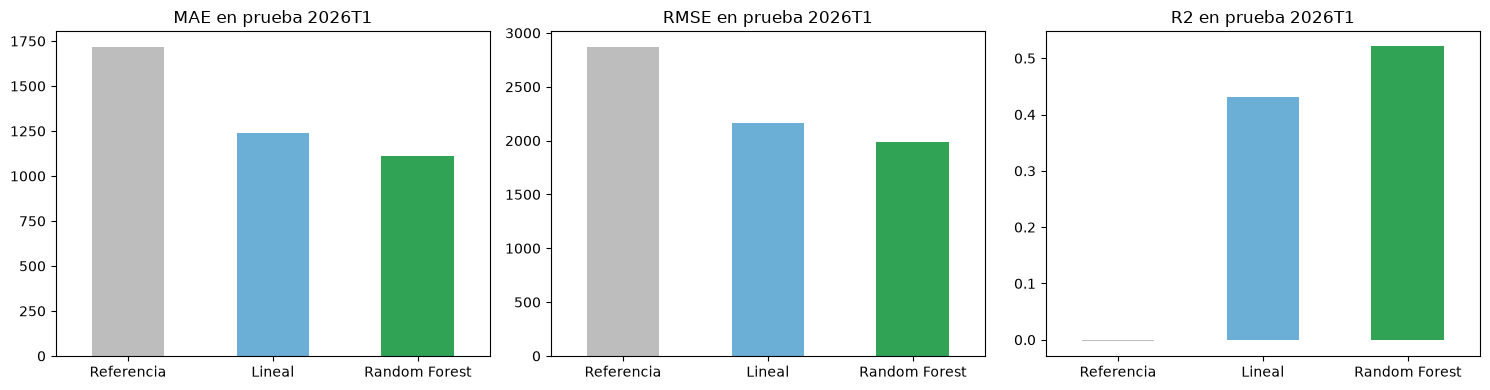

In [74]:
metricas_test = pd.DataFrame(
    [calcular_metricas(resultados_test, "pred_ref"),
     calcular_metricas(resultados_test, "pred_lr"),
     calcular_metricas(resultados_test, "pred_rf")],
    index=["Referencia (media 2025)",
           f"Regresión lineal ({mejor_lr['nombre']})",
           f"Random Forest ({mejor_rf['nombre']})"]
)
print("Métricas en prueba (2026T1):")
display(metricas_test.round(3))

comparacion_final = pd.concat({
    "Validación 2025T4": comparacion_valid,
    "Prueba 2026T1": metricas_test.set_axis(comparacion_valid.index),
}, axis=1)
display(comparacion_final.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["MAE", "RMSE", "R2"]):
    metricas_test[metrica].plot.bar(ax=ax, color=["#bdbdbd", "#6baed6", "#31a354"])
    ax.set_title(f"{metrica} en prueba 2026T1")
    ax.set_xticklabels(["Referencia", "Lineal", "Random Forest"], rotation=0)
plt.tight_layout()
plt.show()

### Interpretación — Evaluación final en 2026T1

Los dos modelos se reentrenaron con todo 2025 (53,025 registros) y se evaluaron con los mismos 13,258 registros de 2026T1.

| Prueba 2026T1 | MAE | RMSE | R² |
|---|---|---|---|
| Referencia (media 2025) | Q1,718 | Q2,871 | 0.00 |
| Regresión lineal | Q1,241 | Q2,164 | 0.431 |
| **Random Forest** | **Q1,114** | **Q1,984** | **0.522** |

- **Generalizan bien:** las métricas de 2026 son casi iguales a las de validación (R² 0.426 → 0.431 en la regresión lineal y 0.515 → 0.522 en Random Forest).
- **Random Forest sigue ganando:** su RMSE es 8% menor que el de la regresión lineal y 31% menor que el de la referencia.
- **Utilidad:** un MAE de Q1,114 equivale a un tercio del salario mediano (Q3,200). Sirve para comparar grupos, no para estimar el salario de una persona.
- **Precaución:** por la rotación del panel, algunas personas de 2026 ya estaban en 2025, lo que puede mejorar un poco las métricas.

## 8. Visualización y análisis de errores

**Definición de residuo:** `residuo = salario_real − salario_predicho`.

- Residuo **positivo**: el modelo **subestima** (predice menos de lo que gana la persona).
- Residuo **negativo**: el modelo **sobreestima**.

Los gráficos usan **la misma muestra de 5,000 registros** de prueba para ambos modelos.
Las tablas por grupo se calculan con **todos** los registros de prueba.

Registros en la muestra gráfica: 5,000


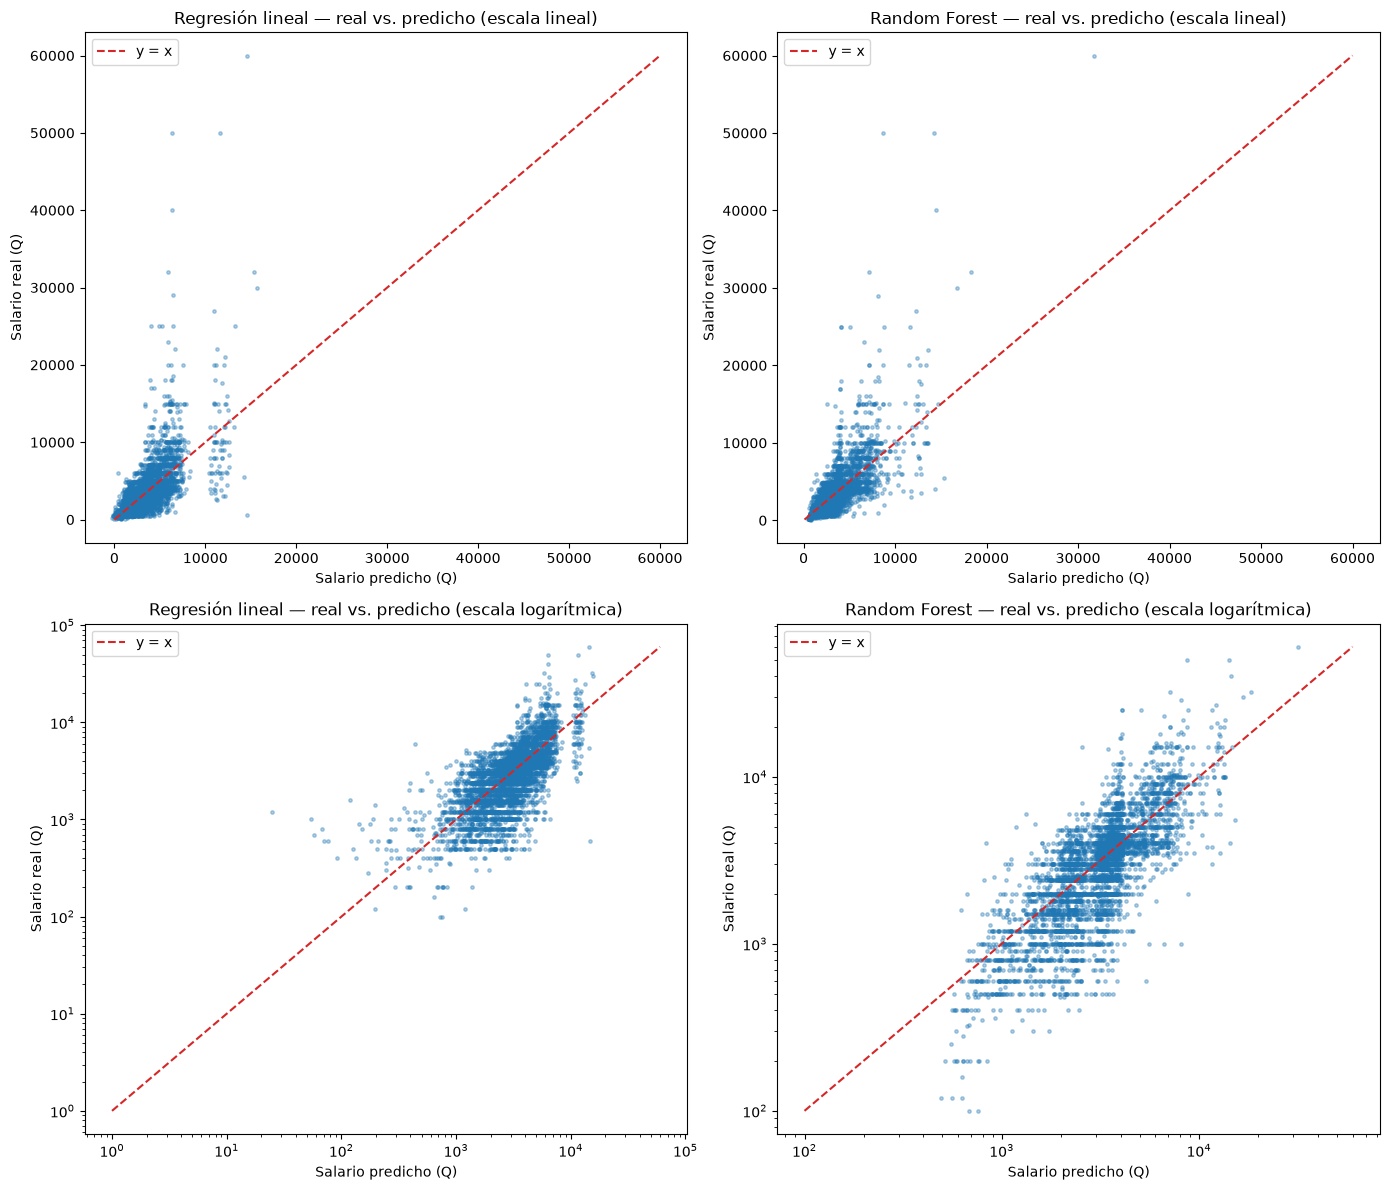

In [75]:
muestra_test = (
    resultados_test
    .sample(False, min(1.0, 6000 / n_eval), seed=SEMILLA)
    .limit(5000)
    .toPandas()
)
print(f"Registros en la muestra gráfica: {len(muestra_test):,}")

modelos_graf = [("pred_lr", "residuo_lr", "Regresión lineal"),
                ("pred_rf", "residuo_rf", "Random Forest")]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for j, (col_pred, _, titulo) in enumerate(modelos_graf):
    for i, escala in enumerate(["linear", "log"]):
        ax = axes[i, j]
        ax.scatter(muestra_test[col_pred], muestra_test[OBJETIVO], s=6, alpha=0.35)
        positivos = muestra_test[[col_pred, OBJETIVO]].clip(lower=1)
        lim = [positivos.min().min(), positivos.max().max()]
        ax.plot(lim, lim, color="#d62728", linestyle="--", label="y = x")
        ax.set_xscale(escala)
        ax.set_yscale(escala)
        ax.set_xlabel("Salario predicho (Q)")
        ax.set_ylabel("Salario real (Q)")
        ax.set_title(f"{titulo} — real vs. predicho (escala {'lineal' if escala == 'linear' else 'logarítmica'})")
        ax.legend()

plt.tight_layout()
plt.show()

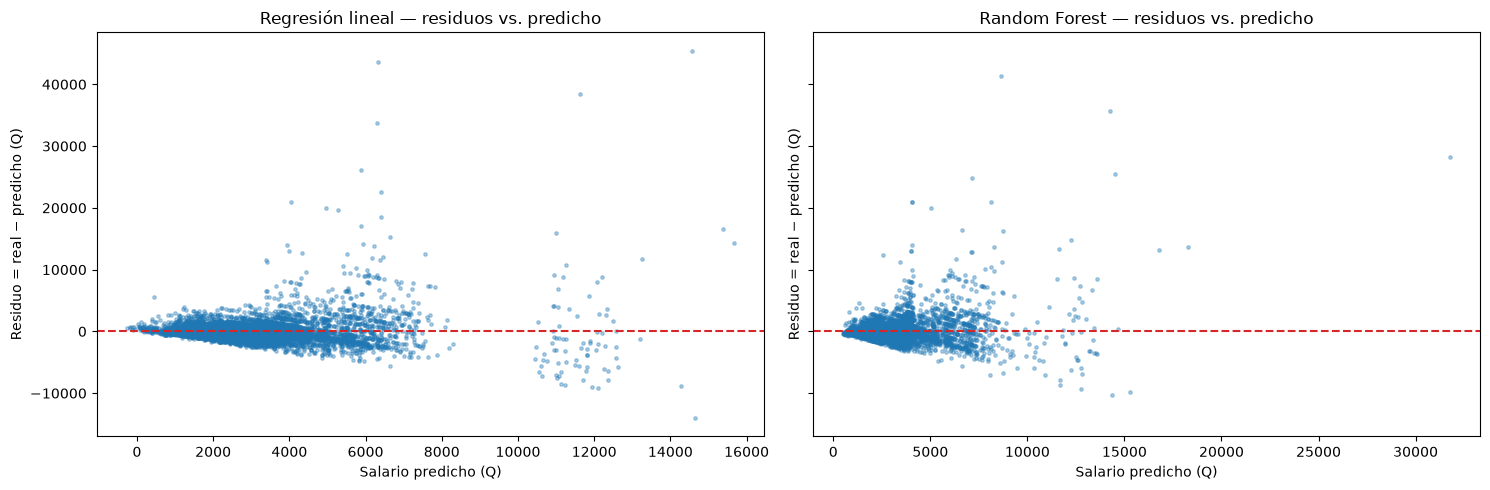

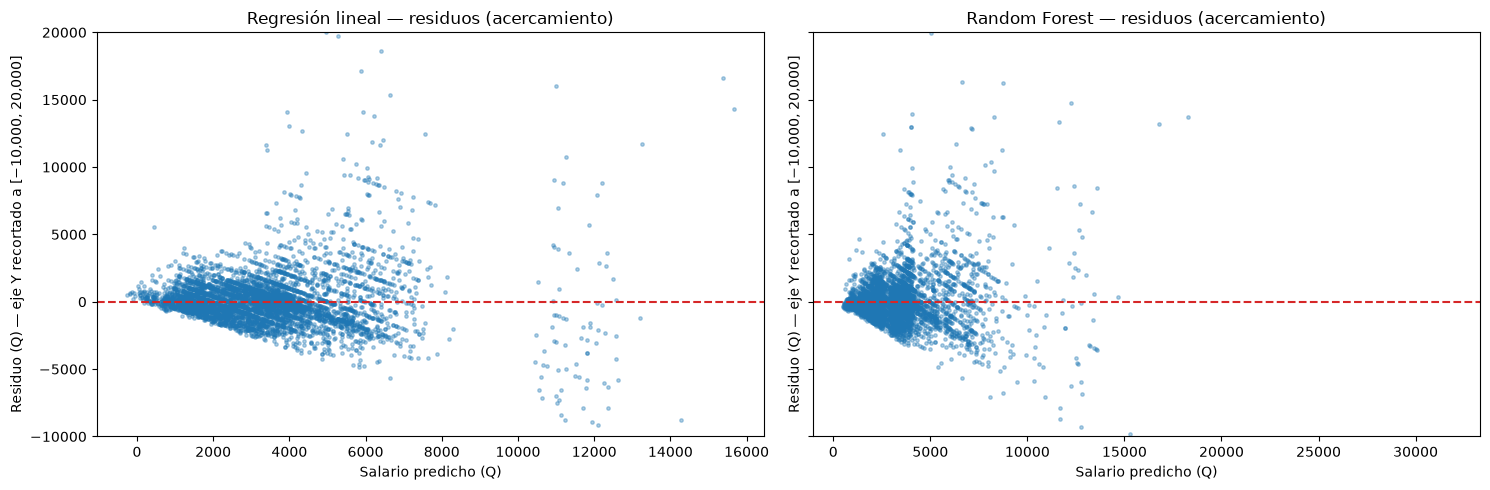

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (col_pred, col_res, titulo) in zip(axes, modelos_graf):
    ax.scatter(muestra_test[col_pred], muestra_test[col_res], s=6, alpha=0.35)
    ax.axhline(0, color="#d62728", linestyle="--")
    ax.set_xlabel("Salario predicho (Q)")
    ax.set_ylabel("Residuo = real − predicho (Q)")
    ax.set_title(f"{titulo} — residuos vs. predicho")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (col_pred, col_res, titulo) in zip(axes, modelos_graf):
    ax.scatter(muestra_test[col_pred], muestra_test[col_res], s=6, alpha=0.35)
    ax.axhline(0, color="#d62728", linestyle="--")
    ax.set_ylim(-10000, 20000)
    ax.set_xlabel("Salario predicho (Q)")
    ax.set_ylabel("Residuo (Q) — eje Y recortado a [−10,000, 20,000]")
    ax.set_title(f"{titulo} — residuos (acercamiento)")

plt.tight_layout()
plt.show()

In [77]:
def errores_por_grupo(df, grupo):
    tabla = (
        df.groupBy(grupo)
        .agg(
            F.count("*").alias("n"),
            F.mean(OBJETIVO).alias("salario_real_medio"),
            F.mean(F.abs("residuo_lr")).alias("MAE_lr"),
            F.mean("residuo_lr").alias("error_medio_lr"),
            F.mean(F.abs("residuo_rf")).alias("MAE_rf"),
            F.mean("residuo_rf").alias("error_medio_rf"),
        )
        .orderBy(grupo)
        .toPandas()
    )
    if grupo in ETIQUETAS:
        tabla.insert(1, "etiqueta", tabla[grupo].map(ETIQUETAS[grupo]))
    return tabla.round(1)


print("Errores por nivel educativo (todos los registros de prueba 2026T1)")
tabla_educ = errores_por_grupo(resultados_test, "nivel_educativo")
display(tabla_educ)

print("Errores por dominio (todos los registros de prueba 2026T1)")
tabla_dom = errores_por_grupo(resultados_test, "dominio")
display(tabla_dom)

Errores por nivel educativo (todos los registros de prueba 2026T1)


,nivel_educativo,etiqueta,n,salario_real_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,0,Ninguno,1016,1884.1,823.5,109.3,660.6,-82.0
1,1,Preprimaria,80,2374.6,735.2,88.8,736.2,-370.5
2,2,Primaria,3957,2422.7,870.0,54.6,763.2,16.5
3,3,Básico,2164,2905.5,894.5,127.8,826.6,-30.1
4,4,Diversificado,4117,3924.2,1109.3,104.0,1024.8,236.7
5,5,Superior,1729,6264.4,2566.4,295.5,2317.1,290.4
6,6,Maestría,183,11290.6,5552.9,-131.5,4694.9,-172.5
7,7,Doctorado,12,20291.7,12919.3,6062.7,11816.5,6547.5


Errores por dominio (todos los registros de prueba 2026T1)


,dominio,etiqueta,n,salario_real_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,1,Urbano metropolitano,5632,4352.3,1446.1,136.0,1320.0,280.5
1,2,Resto urbano,4846,3281.6,1189.6,134.3,1059.8,-3.4
2,3,Rural nacional,2780,2467.7,913.6,65.2,789.7,-54.8


### Errores según el percentil del salario real

Para ver si los modelos subestiman o sobreestiman a quienes ganan más, los registros de
prueba se agrupan según el percentil de su salario **real**. Los percentiles se calculan
sobre los 2026T1 completos.

Percentiles del salario real en prueba (P25, P50, P75, P90, P95, P99): ['Q2,000', 'Q3,200', 'Q4,080', 'Q6,000', 'Q8,000', 'Q15,000']


,grupo_percentil,n,salario_real_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,1. ≤ P25,4032,1297.7,998.4,-828.7,882.9,-808.8
1,2. P25–P50,2715,2738.2,851.7,-161.1,686.0,-206.9
2,3. P50–P75,3200,3770.2,832.9,-82.1,698.2,-32.2
3,4. P75–P90,2060,4893.3,1176.4,493.3,1213.6,552.0
4,5. P90–P95,608,7224.8,2076.1,1634.3,2013.3,1572.0
5,6. P95–P99,545,10722.7,4331.3,4091.7,3911.5,3652.4
6,7. > P99,98,22730.0,14285.4,14285.4,12783.1,12783.1


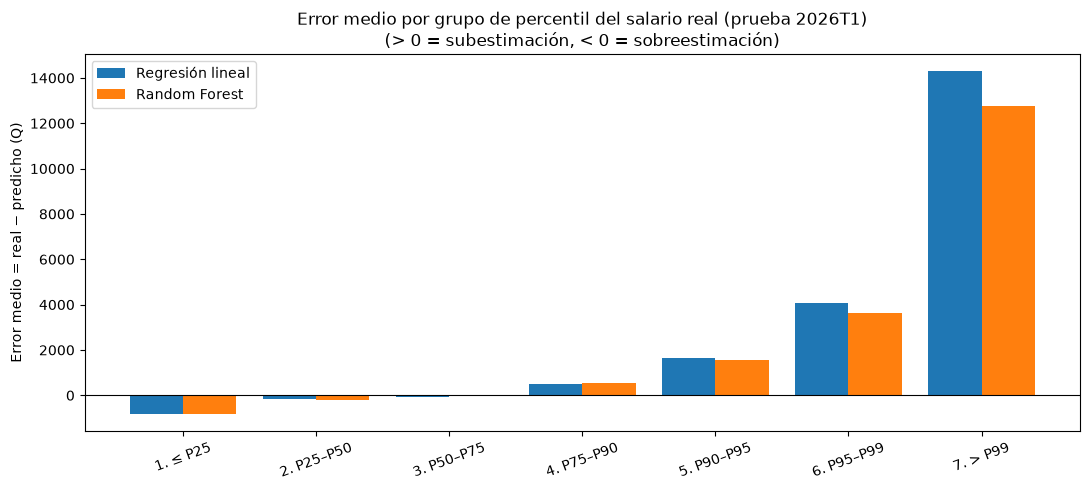

In [78]:
cortes = resultados_test.approxQuantile(OBJETIVO, [0.25, 0.50, 0.75, 0.90, 0.95, 0.99], 0.0)
print("Percentiles del salario real en prueba (P25, P50, P75, P90, P95, P99):",
      [f"Q{c:,.0f}" for c in cortes])

p25, p50, p75, p90, p95, p99 = cortes
salario = F.col(OBJETIVO)

resultados_test_pct = resultados_test.withColumn(
    "grupo_percentil",
    F.when(salario <= p25, "1. ≤ P25")
     .when(salario <= p50, "2. P25–P50")
     .when(salario <= p75, "3. P50–P75")
     .when(salario <= p90, "4. P75–P90")
     .when(salario <= p95, "5. P90–P95")
     .when(salario <= p99, "6. P95–P99")
     .otherwise("7. > P99")
)

tabla_pct = errores_por_grupo(resultados_test_pct, "grupo_percentil")
display(tabla_pct)

x = np.arange(len(tabla_pct))
plt.figure(figsize=(11, 5))
plt.bar(x - 0.2, tabla_pct["error_medio_lr"], width=0.4, label="Regresión lineal")
plt.bar(x + 0.2, tabla_pct["error_medio_rf"], width=0.4, label="Random Forest")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, tabla_pct["grupo_percentil"], rotation=20)
plt.ylabel("Error medio = real − predicho (Q)")
plt.title("Error medio por grupo de percentil del salario real (prueba 2026T1)\n(> 0 = subestimación, < 0 = sobreestimación)")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# Influencia de los salarios extremos en el RMSE (análisis complementario;
# la comparación principal ya se reportó con todos los registros).
influencia = (
    resultados_test
    .withColumn("extremo", F.col(OBJETIVO) > p99)
    .groupBy("extremo")
    .agg(
        F.count("*").alias("n"),
        F.sum(F.pow("residuo_lr", 2)).alias("sse_lr"),
        F.sum(F.pow("residuo_rf", 2)).alias("sse_rf"),
    )
    .toPandas()
)
influencia["pct_registros"] = 100 * influencia["n"] / influencia["n"].sum()
influencia["pct_sse_lr"] = 100 * influencia["sse_lr"] / influencia["sse_lr"].sum()
influencia["pct_sse_rf"] = 100 * influencia["sse_rf"] / influencia["sse_rf"].sum()
display(influencia[["extremo", "n", "pct_registros", "pct_sse_lr", "pct_sse_rf"]].round(2))

sin_extremos = resultados_test.filter(F.col(OBJETIVO) <= p99)
print("Sensibilidad (solo descriptiva): métricas excluyendo el 1% de salarios más altos")
display(pd.DataFrame(
    [calcular_metricas(sin_extremos, "pred_lr"), calcular_metricas(sin_extremos, "pred_rf")],
    index=["Regresión lineal", "Random Forest"]
).round(3))

,extremo,n,pct_registros,pct_sse_lr,pct_sse_rf
0,True,98,0.74,41.1,38.97
1,False,13160,99.26,58.9,61.03


Sensibilidad (solo descriptiva): métricas excluyendo el 1% de salarios más altos


,MAE,RMSE,R2
Regresión lineal,1143.569,1666.742,0.453
Random Forest,1026.798,1555.400,0.524


### Interpretación — Análisis de errores

**Gráficos**
- Los residuos forman un **abanico**: el error crece con el salario (heterocedasticidad).
- Los residuos grandes son casi todos **positivos**: los salarios altos se subestiman.
- La mayoría de las predicciones está bajo Q8,000, aunque hay salarios reales de hasta Q60,000.
- La regresión lineal da algunas **predicciones negativas**, algo imposible para un salario. Random Forest no, porque promedia salarios reales.
- El borde diagonal inferior de los residuos existe porque el salario no puede ser negativo.

**Por nivel educativo**
- El MAE sube con la educación: de Q824 (ninguno) a Q2,566 (superior) y Q5,553 (maestría) en la regresión lineal. Random Forest sigue el mismo patrón con errores menores.
- El error medio es pequeño (Q50–Q300) en casi todos los niveles.
- Doctorado se subestima en más de Q6,000, pero solo tiene 12 registros.

**Por dominio**
- El MAE es mayor en el área metropolitana (Q1,446 en la regresión lineal y Q1,320 en Random Forest) que en el área rural (Q914 / Q790), porque ahí los salarios son más altos.
- El error medio es cercano a cero en todos los dominios: no hay sesgo por dominio.

**Por percentil del salario real**

| Grupo | Error medio (regresión lineal / Random Forest) | Lectura |
|---|---|---|
| ≤ P25 (≤ Q2,000) | −Q829 / −Q809 | Sobreestima |
| P25–P75 | −Q207 a −Q32 | Casi sin sesgo |
| P75–P90 | +Q493 / +Q552 | Subestima levemente |
| P90–P95 | +Q1,634 / +Q1,572 | Subestima |
| P95–P99 | +Q4,092 / +Q3,652 | Subestima |
| > P99 (> Q15,000) | +Q14,285 / +Q12,783 | Subestima **todos** los casos |

**Conclusión:** los dos modelos jalan las predicciones hacia el centro (regresión hacia la
media). Los salarios bajos se sobreestiman y los altos se subestiman.

**Extremos:** el 1% de salarios más altos (98 registros) genera el **41% (regresión lineal) y el 39% (Random Forest)**
del error cuadrático. Sin ellos, el RMSE bajaría a Q1,667 y Q1,555. Este cálculo es solo
descriptivo; la comparación oficial conserva todos los registros. Por eso el RMSE se debe leer
junto con el MAE.

## Discusión final

**Datos**
- 53,025 asalariados en 2025 y 13,258 en 2026T1 (alrededor del 26% de cada archivo), con los mismos filtros en el mismo orden.
- No hay claves duplicadas ni valores `DESCONOCIDO` en la población analítica.
- Los resultados son **no ponderados**. Para hacer estimaciones del país habría que usar `FACTOR` y el diseño muestral.

**Salario**
- Distribución muy asimétrica: media Q3,422, mediana Q3,000 y máximo Q99,000.
- Lo diferencian la educación (de Q1,500 a Q12,000 de mediana) y la categoría ocupacional (de Q1,000 en servicio doméstico a Q5,000 en gobierno).
- La edad, la antigüedad y las horas tienen correlaciones débiles con el salario (r ≤ 0.18).

**Perfiles (KMeans, K = 4, sin salario)**
- Jóvenes al inicio de su carrera (46%), adultos con poca antigüedad (24%), jornadas extendidas (17%) y trabajadores consolidados (13%).
- Solo los consolidados ganan claramente más (mediana de Q3,800). Trabajar 75 horas semanales no sube el salario mensual.

**Predicción**
- Los dos modelos superan a la referencia. **Random Forest es el mejor**: R² 0.522, RMSE Q1,984 y MAE Q1,114 en 2026.
- La regresión lineal (R² 0.431) no capta no linealidades ni interacciones. Regularizarla no ayudó.
- El desempeño se mantuvo estable de validación a prueba.

**Errores**
- Crecen con el nivel salarial y educativo.
- Sesgo sistemático: los salarios bajos se sobreestiman y los altos se subestiman.
- El 1% de salarios más altos genera cerca del 40% del error cuadrático.

**Respuestas a las preguntas del laboratorio**
- *¿Qué perfiles hay?* Cuatro, definidos por la etapa de la carrera (edad y antigüedad) y la duración de la jornada.
- *¿Qué tan bien se estima el salario?* De forma moderada: se explica cerca de la mitad de la variabilidad (R² ≈ 0.52). Sirve para comparar grupos, no para estimar el salario de una persona, y los salarios altos quedan subestimados.

**Limitaciones**
- Faltan predictores importantes: ocupación, rama de actividad, tamaño de la empresa, departamento y formalidad.
- Las observaciones repetidas del panel no son independientes.
- Como extensión se podría modelar el logaritmo del salario o usar regresión por cuantiles.
- Todo lo encontrado son asociaciones: no demuestran causalidad ni indican cuánto debería ganar una persona.